In [2]:
# ==============================================================================
# 0. ENVIRONMENT SETUP & VISUAL STYLING
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Professional chart styling for LinkedIn / Reports
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Liberation Sans", "sans-serif"],
    "figure.titlesize": 14,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.autolayout": True,
    "figure.dpi": 150
})

print("Setup completed successfully.")

Setup completed successfully.


# Chapter 1: The Macroeconomic Baseline (August 2022)

### 1.1 Executive Summary & Historical Context
When the administration of Gustavo Petro assumed office in August 2022, Colombia was navigating a dual macroeconomic reality:
1. **High Real Output Growth:** A robust post-pandemic statistical rebound (GDP grew 10.8% in 2021 and 7.3% in 2022), driven primarily by private consumption and credit expansion.
2. **Severe Macroeconomic Imbalances:**
   - **Galloping Inflation:** Headline CPI stood at **10.84% YoY** in August 2022 (accelerating towards 13.12% by year-end), pushed by global supply-chain disruptions and severe local food price inflation.
   - **Monetary Tightening:** *Banco de la República* was in the middle of a steep rate-hiking cycle, having raised the benchmark policy rate from 1.75% in September 2021 to **9.00%** by August 2022.
   - **The Fuel Subsidy Overhang (FEPC):** An accumulated deficit in the Fuel Price Stabilization Fund (*Fondo de Estabilización de Precios de los Combustibles*) totaling nearly **COP 36 trillion (~2.5% of GDP)**, caused by freezing domestic gasoline and diesel prices far below international parity.
   - **Twin Deficits:** A Central Government fiscal deficit of **-5.3% of GDP** paired with an external Current Account deficit exceeding **-6.2% of GDP**, leaving the Colombian Peso vulnerable to external shocks.

### 1.2 Quantitative Baseline Matrix
The table and visual below establish the starting benchmark across Colombia's core macroeconomic variables as of August 2022.

--- COLOMBIA MACROECONOMIC BASELINE: AUGUST 2022 ---
                                Indicator  Value     Unit             Type
       Annual GDP Growth (2022 Full Year)   7.30        %    Real Activity
   Headline Inflation (CPI YoY, Aug 2022)  10.84        %  Nominal / Price
      Central Bank Policy Rate (Aug 2022)   9.00        %  Monetary Policy
    National Unemployment Rate (Aug 2022)  10.60        %     Labor Market
    Current Account Deficit (% GDP, 2022)  -6.20 % of GDP External Balance
Central Govt Fiscal Deficit (% GDP, 2022)  -5.30 % of GDP   Fiscal Balance


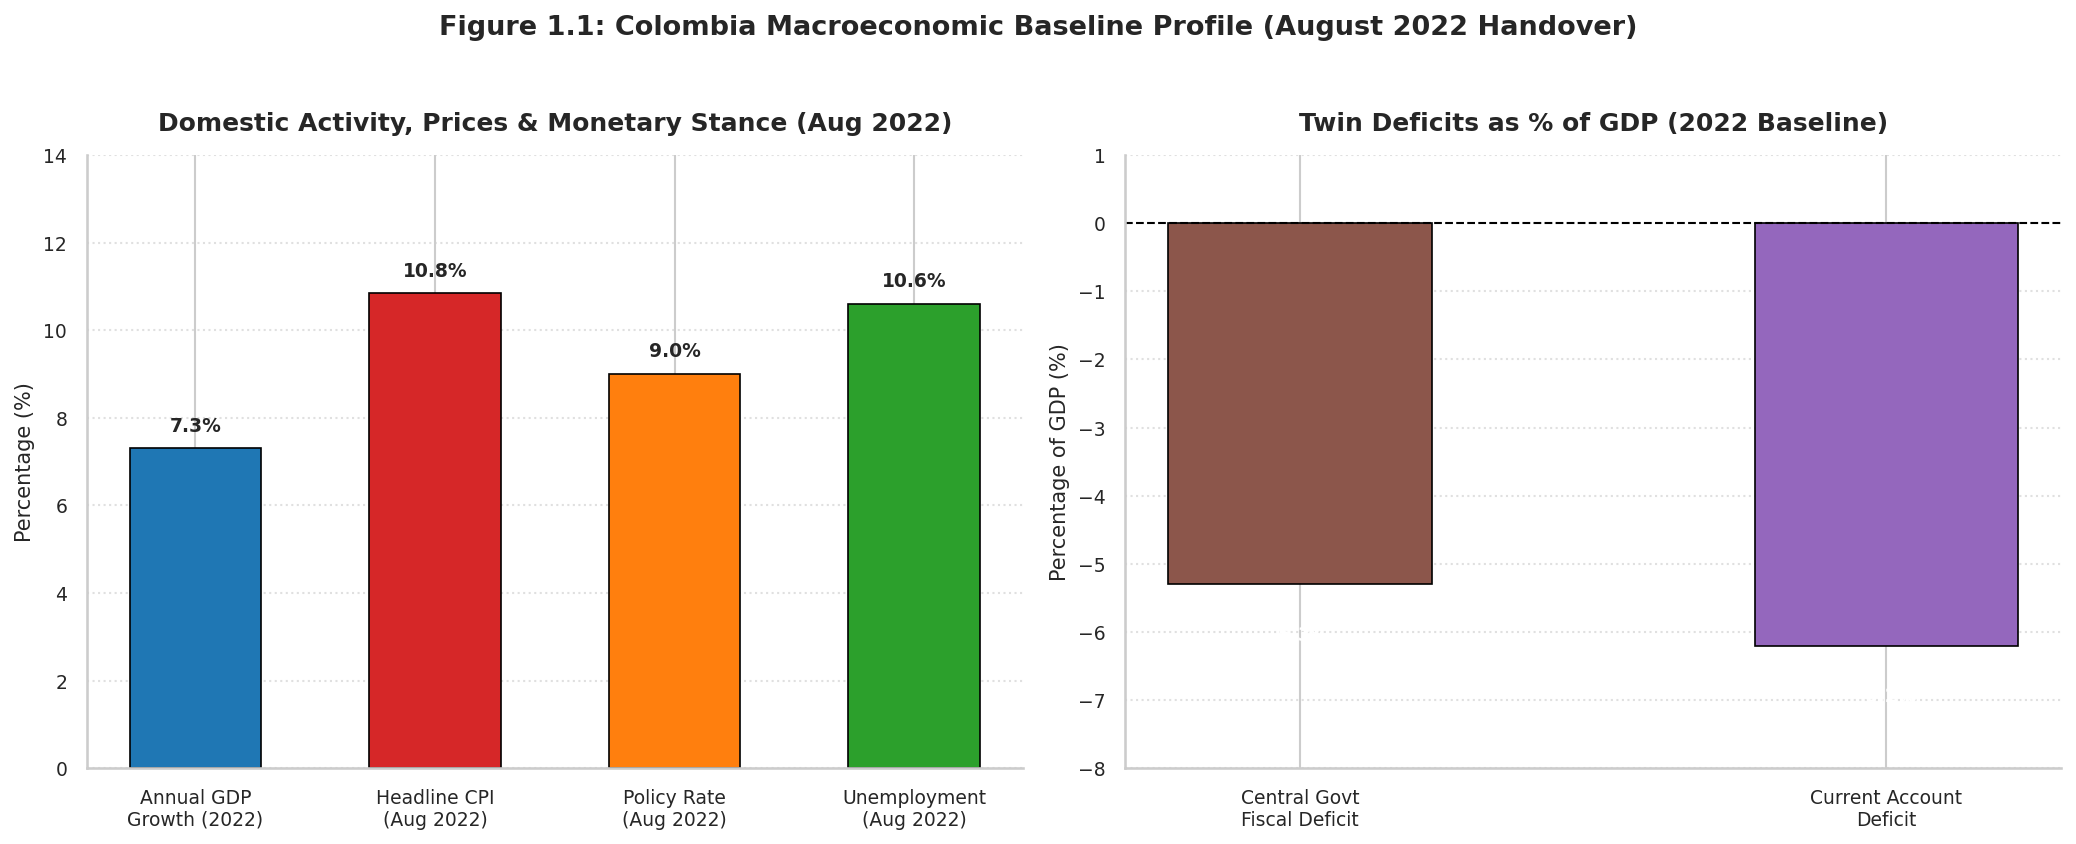

In [3]:
# ==============================================================================
# CHAPTER 1: BASELINE MACROECONOMIC INDICATORS (AUGUST 2022)
# Data Sources: DANE, Banco de la República, MinHacienda / CARF
# ==============================================================================

# 1. Baseline Dataset Construction
baseline_data = {
    "Indicator": [
        "Annual GDP Growth (2022 Full Year)",
        "Headline Inflation (CPI YoY, Aug 2022)",
        "Central Bank Policy Rate (Aug 2022)",
        "National Unemployment Rate (Aug 2022)",
        "Current Account Deficit (% GDP, 2022)",
        "Central Govt Fiscal Deficit (% GDP, 2022)"
    ],
    "Value": [7.3, 10.84, 9.00, 10.60, -6.20, -5.30],
    "Unit": ["%", "%", "%", "%", "% of GDP", "% of GDP"],
    "Type": ["Real Activity", "Nominal / Price", "Monetary Policy", "Labor Market", "External Balance", "Fiscal Balance"],
    "Direction": ["Positive", "Pressure", "Restrictive", "Structural", "Deficit", "Deficit"]
}

df_baseline = pd.DataFrame(baseline_data)

# Display tabular summary
print("--- COLOMBIA MACROECONOMIC BASELINE: AUGUST 2022 ---")
print(df_baseline[["Indicator", "Value", "Unit", "Type"]].to_string(index=False))

# 2. Visual Representation: Baseline Dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Palette setup
colors = ["#2b5c8f", "#d95f02", "#7570b3", "#e7298a", "#e6ab02", "#a6761d"]

# Left Panel: Nominal and Real Rates
rates_labels = [
    "Annual GDP\nGrowth (2022)",
    "Headline CPI\n(Aug 2022)",
    "Policy Rate\n(Aug 2022)",
    "Unemployment\n(Aug 2022)"
]
rates_values = [7.3, 10.84, 9.00, 10.60]

bars1 = axes[0].bar(rates_labels, rates_values, color=["#1f77b4", "#d62728", "#ff7f0e", "#2ca02c"], width=0.55, edgecolor="black", linewidth=0.8)
axes[0].set_title("Domestic Activity, Prices & Monetary Stance (Aug 2022)", fontweight="bold", pad=12)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 14)

# Data labels on bars
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f"{yval:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=9)

# Right Panel: Twin Deficits (Fiscal & External Balances)
deficit_labels = [
    "Central Govt\nFiscal Deficit",
    "Current Account\nDeficit"
]
deficit_values = [-5.3, -6.2]

bars2 = axes[1].bar(deficit_labels, deficit_values, color=["#8c564b", "#9467bd"], width=0.45, edgecolor="black", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=1.0, linestyle="--")
axes[1].set_title("Twin Deficits as % of GDP (2022 Baseline)", fontweight="bold", pad=12)
axes[1].set_ylabel("Percentage of GDP (%)")
axes[1].set_ylim(-8, 1)

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval - 0.6, f"{yval:.1f}%", ha="center", va="top", fontweight="bold", fontsize=9, color="white")

# General visual tweaks
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.suptitle("Figure 1.1: Colombia Macroeconomic Baseline Profile (August 2022 Handover)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 1.3 Analytical Takeaways & Baseline Diagnosis

1. **The Illusion of High Growth:** The headline growth rate of **7.3% in 2022** was primarily an extension of the post-lockdown consumption rebound. It was characterized by high household leverage and private consumption rather than sustainable capital accumulation.
2. **An Economy Operating Above Potential:** With double-digit inflation (**10.84%**) and an aggressive rate-hiking stance (**9.00%** and rising), the economy entered August 2022 showing clear symptoms of overheating, which required a sharp subsequent deceleration to stabilize price dynamics.
3. **Severe Structural Vulnerability (Twin Deficits):** The combination of a **-5.3% fiscal deficit** and a **-6.2% current account deficit** meant Colombia was heavily dependent on external capital inflows. This structural vulnerability, coupled with domestic uncertainty, set the stage for the currency depreciation shock observed in Q3–Q4 2022 (where the exchange rate temporarily neared COP 5,000 / USD).
4. **The Unfunded Energy Liability:** The inherited FEPC deficit represented an unavoidable fiscal dilemma: either maintain the subsidies at an unsustainable fiscal cost (~COP 36 trillion) or gradually double domestic gasoline prices, generating direct upward pressure on regulated CPI inflation.

# Chapter 2: Economic Growth, Capital Formation & Sectoral Divergence

### 2.1 Macroeconomic Adjustment and Output Deceleration
Following the unsustainable consumption-led expansion of 2021–2022 (10.8% and 7.3% real GDP growth, respectively), Colombia underwent a sharp cyclical slowdown. Between 2023 and 2024, output adjusted toward its long-term potential as high borrowing costs and political/regulatory uncertainties weighed on domestic demand.

Key features of this growth trajectory:
1. **The 2023 Stagnation:** Real GDP expanded by just **0.6% in 2023**, narrowly avoiding a technical recession as household consumption decelerated and fixed investment collapsed.
2. **Subdued Recovery (2024–2026):** Economic activity experienced a gradual, sub-trend rebound—recovering to ~1.6% in 2024 and stabilizing near 2.3%–2.5% across 2025–2026, below historical pre-pandemic averages.
3. **The Investment Slump (Gross Fixed Capital Formation):** Capital expenditure experienced its steepest contraction since the 1999 financial crisis, falling by double digits (-8.6% in 2023) and remaining historically low as a percentage of GDP (~15% vs. the 21% historical norm).
4. **Sectoral Polarization:** Public administration, social services, and agriculture buffered aggregate GDP, while interest-rate-sensitive and regulatory-dependent sectors (residential construction, manufacturing, and commerce) contracted sharply.

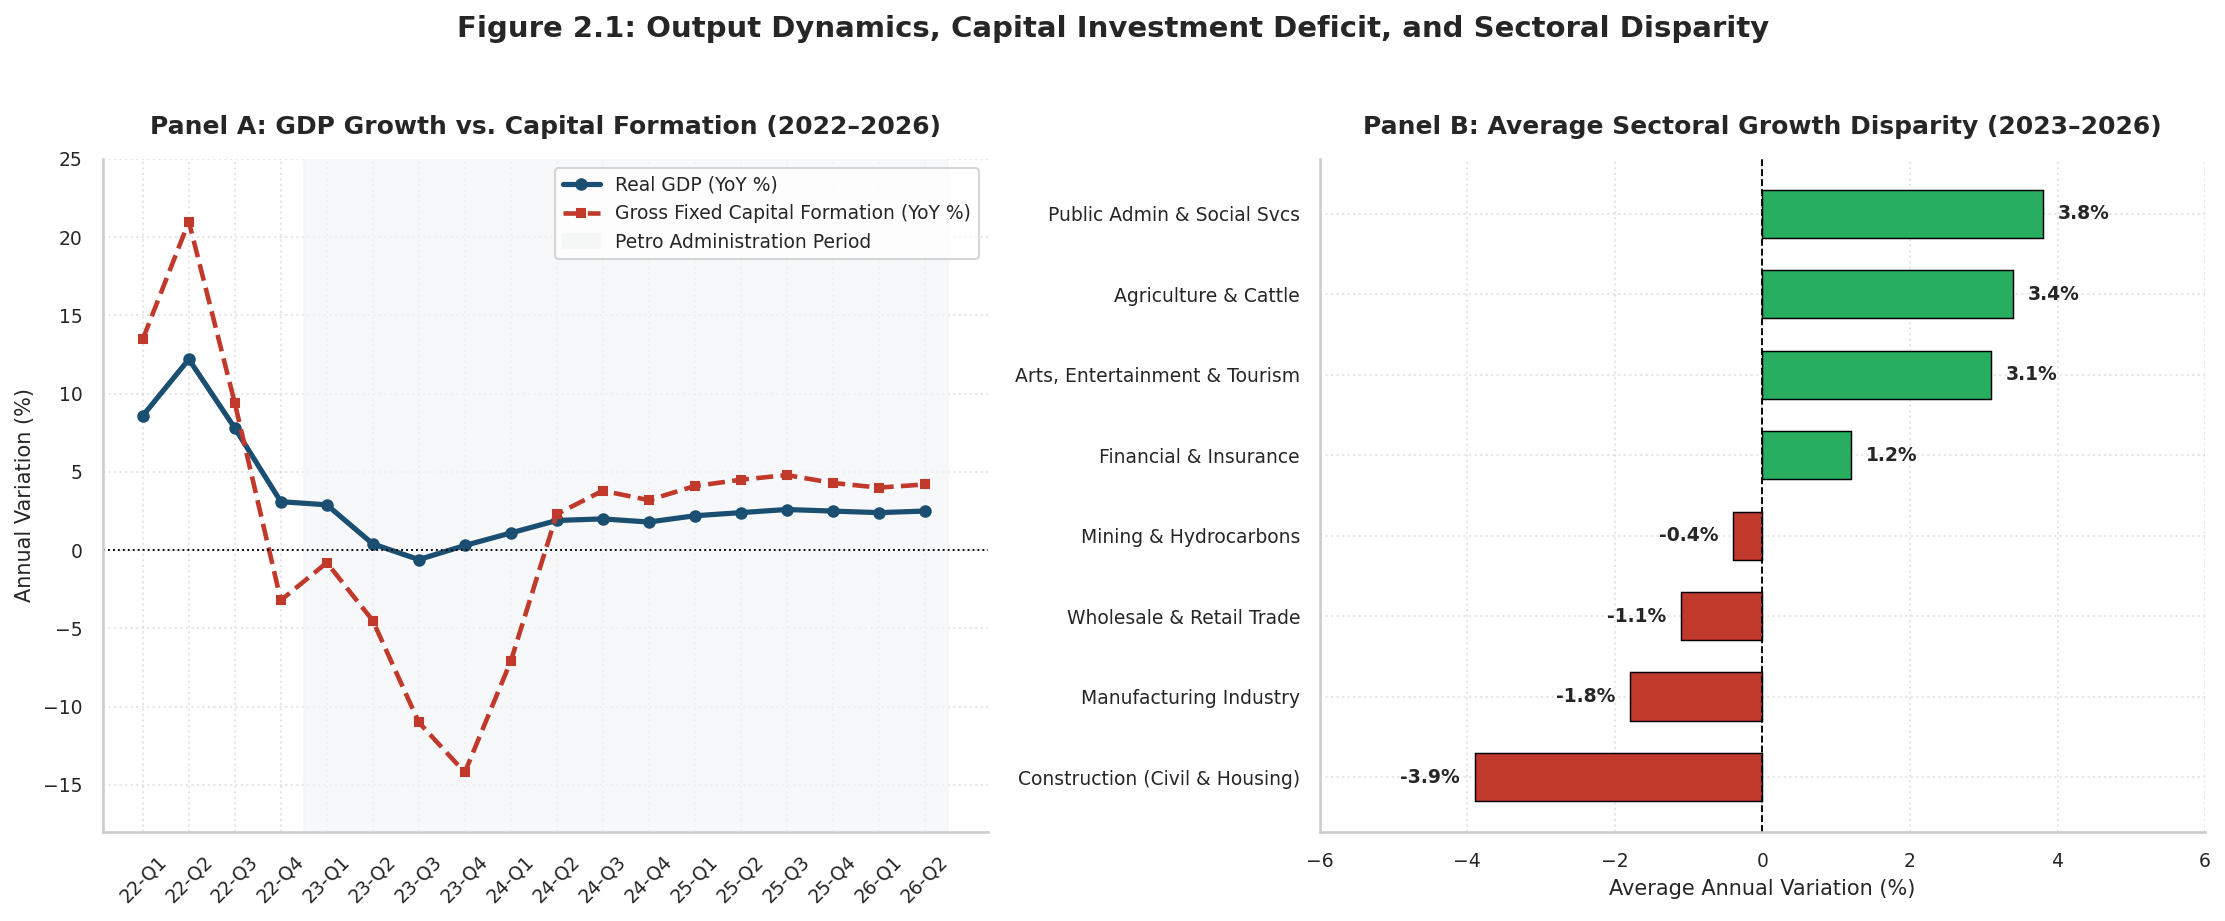

In [4]:
# ==============================================================================
# CHAPTER 2: ECONOMIC GROWTH, INVESTMENT & SECTORAL DIVERGENCE (2022 - 2026)
# Data Sources: DANE (Cuentas Nacionales Trimestrales & ISE)
# ==============================================================================

# 1. Quarterly Macroeconomic Series: Real GDP vs. Gross Fixed Capital Formation (YoY %)
quarterly_data = {
    "Quarter": [
        "22-Q1", "22-Q2", "22-Q3", "22-Q4",
        "23-Q1", "23-Q2", "23-Q3", "23-Q4",
        "24-Q1", "24-Q2", "24-Q3", "24-Q4",
        "25-Q1", "25-Q2", "25-Q3", "25-Q4",
        "26-Q1", "26-Q2"
    ],
    "GDP_YoY": [
        8.6, 12.2, 7.8, 3.1,
        2.9, 0.4, -0.6, 0.3,
        1.1, 1.9, 2.0, 1.8,
        2.2, 2.4, 2.6, 2.5,
        2.4, 2.5
    ],
    "Investment_YoY": [
        13.5, 21.0, 9.4, -3.2,
        -0.8, -4.5, -11.0, -14.2,
        -7.1, 2.3, 3.8, 3.2,
        4.1, 4.5, 4.8, 4.3,
        4.0, 4.2
    ]
}

df_growth = pd.DataFrame(quarterly_data)

# 2. Sectoral Performance Profile: Compound / Average Annual Growth (2023–2025/26)
sectoral_data = {
    "Sector": [
        "Public Admin & Social Svcs",
        "Agriculture & Cattle",
        "Arts, Entertainment & Tourism",
        "Financial & Insurance",
        "Mining & Hydrocarbons",
        "Wholesale & Retail Trade",
        "Manufacturing Industry",
        "Construction (Civil & Housing)"
    ],
    "Avg_Growth": [3.8, 3.4, 3.1, 1.2, -0.4, -1.1, -1.8, -3.9]
}

df_sectors = pd.DataFrame(sectoral_data).sort_values(by="Avg_Growth", ascending=True)

# 3. Visualization: Dual-Panel Dashboard
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: GDP vs. Investment Dynamics (Time Series)
axes[0].plot(df_growth["Quarter"], df_growth["GDP_YoY"], label="Real GDP (YoY %)", color="#1b4f72", linewidth=2.5, marker="o", markersize=5)
axes[0].plot(df_growth["Quarter"], df_growth["Investment_YoY"], label="Gross Fixed Capital Formation (YoY %)", color="#c0392b", linewidth=2.2, linestyle="--", marker="s", markersize=4)

axes[0].axhline(0, color="black", linewidth=0.9, linestyle=":")
axes[0].axvspan(3.5, 17.5, color="#f4f6f7", alpha=0.7, label="Petro Administration Period")

axes[0].set_title("Panel A: GDP Growth vs. Capital Formation (2022–2026)", fontweight="bold", pad=12)
axes[0].set_ylabel("Annual Variation (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(loc="upper right", frameon=True)
axes[0].set_ylim(-18, 25)

# Panel 2: Sectoral Disparities (Horizontal Bar Chart)
bar_colors = ["#c0392b" if val < 0 else "#27ae60" for val in df_sectors["Avg_Growth"]]
bars = axes[1].barh(df_sectors["Sector"], df_sectors["Avg_Growth"], color=bar_colors, edgecolor="black", linewidth=0.7, height=0.6)

axes[1].axvline(0, color="black", linewidth=0.9, linestyle="--")
axes[1].set_title("Panel B: Average Sectoral Growth Disparity (2023–2026)", fontweight="bold", pad=12)
axes[1].set_xlabel("Average Annual Variation (%)")
axes[1].set_xlim(-6, 6)

for bar in bars:
    width = bar.get_width()
    offset = 0.2 if width >= 0 else -0.2
    align = "left" if width >= 0 else "right"
    axes[1].text(width + offset, bar.get_y() + bar.get_height()/2.0, f"{width:.1f}%", ha=align, va="center", fontweight="bold", fontsize=9)

# Aesthetics and formatting
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="both", linestyle=":", alpha=0.5)

plt.suptitle("Figure 2.1: Output Dynamics, Capital Investment Deficit, and Sectoral Disparity", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Analytical Takeaways & Structural Diagnostic

1. **The Capital Investment Slump:** Panel A illustrates that while headline GDP stabilized around a 2.0%–2.5% baseline, **Gross Fixed Capital Formation underwent a protracted contraction**, registering four consecutive quarters of severe negative territory in 2023 (-11.0% in Q3 and -14.2% in Q4). High capital costs combined with institutional and regulatory uncertainty in healthcare, mining, and public utilities drove total investment down to ~15% of GDP—a level insufficient to sustain long-term potential GDP above 3.0%.
2. **Divergent Growth Drivers:** Panel B highlights an economic model sustained primarily by countercyclical public consumption (**Public Administration grew +3.8%**) and weather-normalized **Agriculture (+3.4%)**, rather than broad-based industrialization.
3. **The Industrial & Construction Impasse:** Manufacturing (-1.8%) and Construction (-3.9%) acted as the primary drags on output. Housing construction in particular suffered from the conjunction of elevated mortgage interest rates, high input costs, and operational bottlenecks in the execution of the flagship national housing subsidy program (*Mi Casa Ya*).

# Chapter 3: Inflation, Purchasing Power & Monetary Policy

### 3.1 The Inflationary Surge and Disinflationary Trajectory
Between 2022 and 2026, Colombia confronted the most aggressive inflationary cycle in more than two decades, driven by a sequence of supply and cost-push shocks:
1. **The Peak and Driver Rotation:** Headline CPI peaked at **13.34% YoY in March 2023**. Initially, the surge was led by **Food and Non-Alcoholic Beverages**, which skyrocketed past **27.8% YoY in late 2022** due to global fertilizer shortages, currency depreciation, and heavy rainfall from *La Niña*.
2. **The FEPC Dilemma (Regulated Inflation Stickiness):** As food inflation rapidly normalized throughout 2023–2024, disinflation was slowed down by **Regulated Prices (which hovered above 13%–17%)**. To close the multi-billion dollar deficit in the Fuel Price Stabilization Fund (*FEPC*), the national government orchestrated a planned adjustment of domestic gasoline prices, raising them from ~$9,100 COP/gallon in mid-2022 to over ~$15,500 COP/gallon by early 2024.
3. **The Central Bank's Restrictive Stance:** *Banco de la República* carried out an aggressive tightening cycle, taking the benchmark intervention rate to a terminal peak of **13.25% in April 2023** and holding it there until December 2023. As headline inflation receded, real interest rates turned deeply positive (+400 to +600 bps), deliberately cooling domestic consumption and credit.

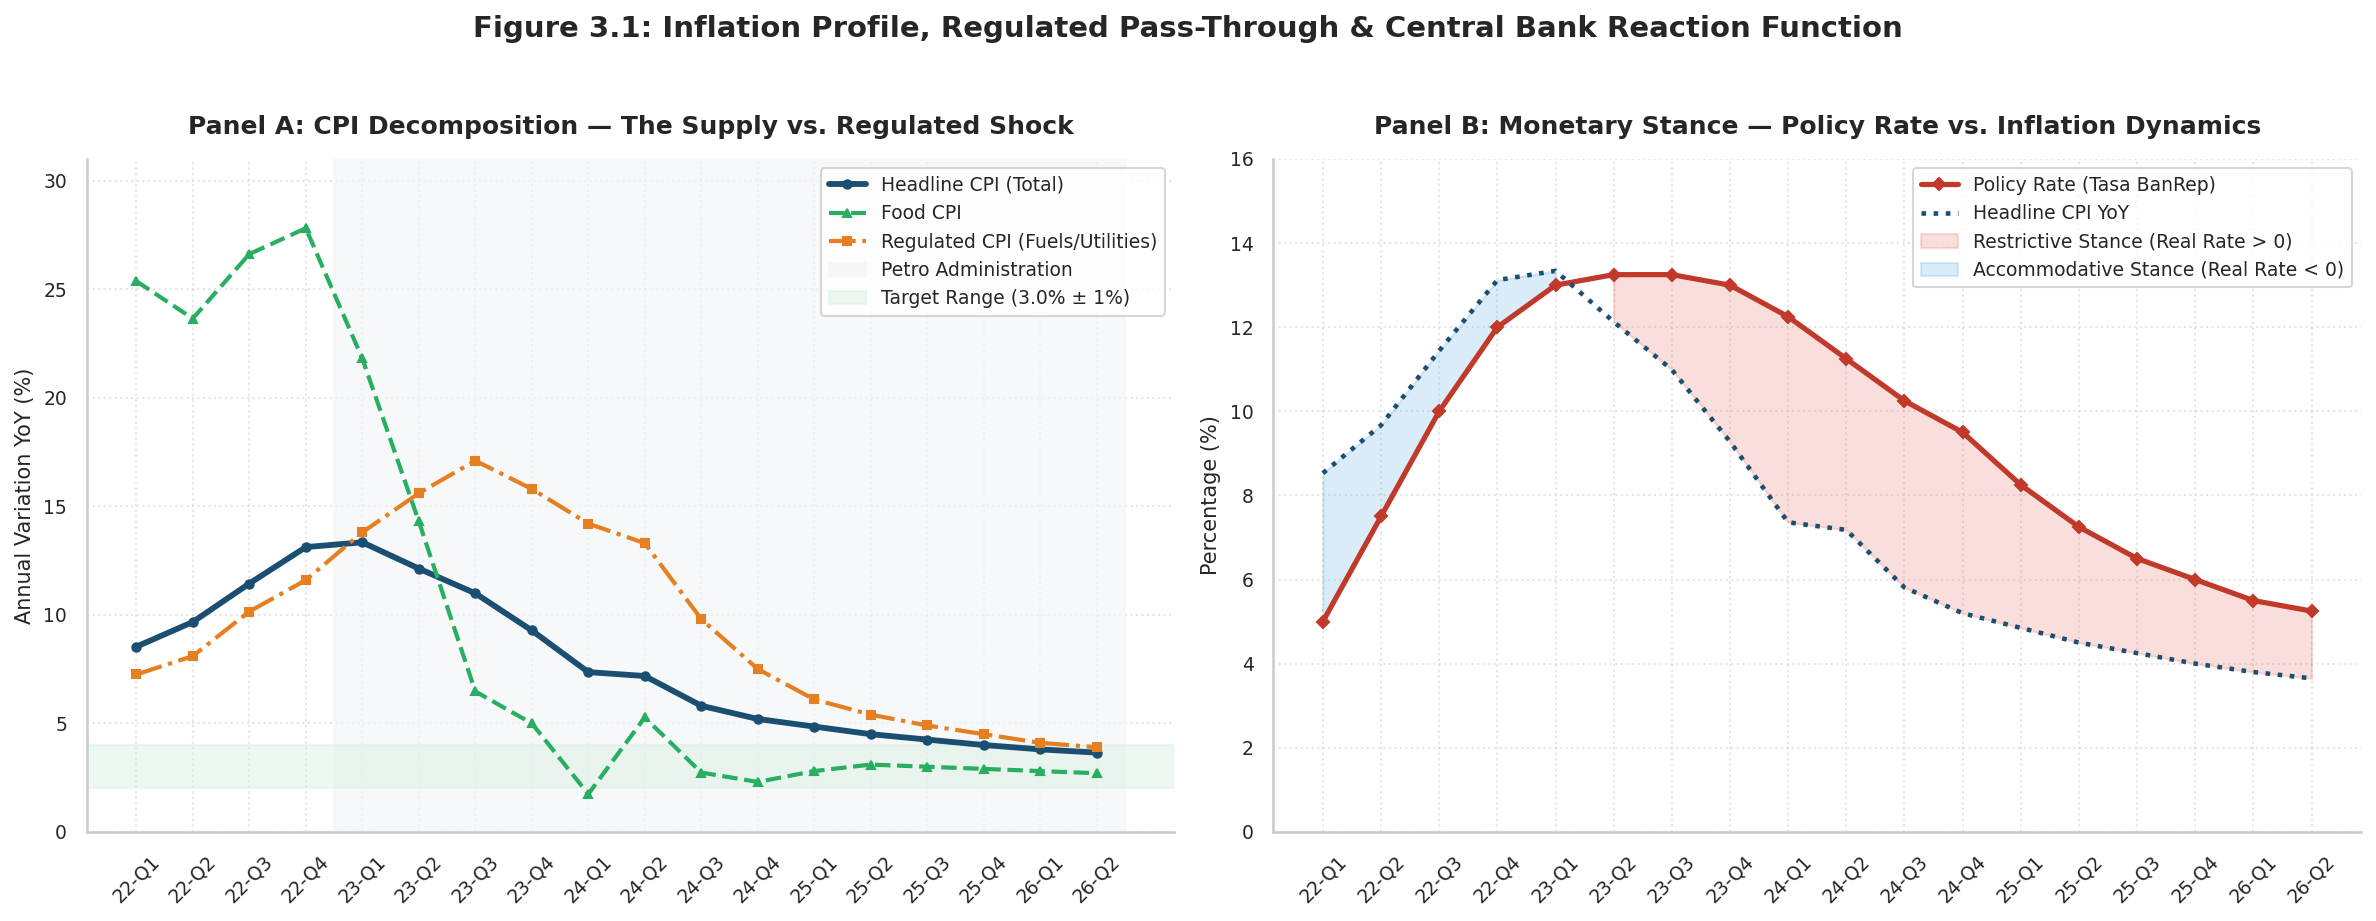

In [5]:
# ==============================================================================
# CHAPTER 3: INFLATION DYNAMICS & MONETARY POLICY TRANSMISSION (2022 - 2026)
# Data Sources: DANE (IPC) & Banco de la República (Tasa de Intervención)
# ==============================================================================

# 1. Quarterly Macro Time Series: CPI Components vs. Policy Rate
cpi_monetary_data = {
    "Quarter": [
        "22-Q1", "22-Q2", "22-Q3", "22-Q4",
        "23-Q1", "23-Q2", "23-Q3", "23-Q4",
        "24-Q1", "24-Q2", "24-Q3", "24-Q4",
        "25-Q1", "25-Q2", "25-Q3", "25-Q4",
        "26-Q1", "26-Q2"
    ],
    "Headline_CPI": [
        8.53, 9.67, 11.44, 13.12,
        13.34, 12.13, 10.99, 9.28,
        7.36, 7.18, 5.81, 5.20,
        4.85, 4.50, 4.25, 4.00,
        3.80, 3.65
    ],
    "Food_CPI": [
        25.37, 23.65, 26.62, 27.81,
        21.81, 14.31, 6.47, 5.00,
        1.74, 5.27, 2.73, 2.30,
        2.80, 3.10, 3.00, 2.90,
        2.80, 2.70
    ],
    "Regulated_CPI": [
        7.25, 8.10, 10.15, 11.60,
        13.80, 15.60, 17.10, 15.80,
        14.20, 13.30, 9.80, 7.50,
        6.10, 5.40, 4.90, 4.50,
        4.10, 3.90
    ],
    "Policy_Rate": [
        5.00, 7.50, 10.00, 12.00,
        13.00, 13.25, 13.25, 13.00,
        12.25, 11.25, 10.25, 9.50,
        8.25, 7.25, 6.50, 6.00,
        5.50, 5.25
    ]
}

df_inflation = pd.DataFrame(cpi_monetary_data)

# 2. Visualization: Dual-Panel Macro Dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: CPI Breakdown (Headline vs. Food vs. Regulated)
axes[0].plot(df_inflation["Quarter"], df_inflation["Headline_CPI"], label="Headline CPI (Total)", color="#1b4f72", linewidth=2.8, marker="o", markersize=4)
axes[0].plot(df_inflation["Quarter"], df_inflation["Food_CPI"], label="Food CPI", color="#27ae60", linewidth=2.0, linestyle="--", marker="^", markersize=4)
axes[0].plot(df_inflation["Quarter"], df_inflation["Regulated_CPI"], label="Regulated CPI (Fuels/Utilities)", color="#e67e22", linewidth=2.0, linestyle="-.", marker="s", markersize=4)

axes[0].axvspan(3.5, 17.5, color="#f4f6f7", alpha=0.7, label="Petro Administration")
axes[0].axhspan(2.0, 4.0, color="#d4efdf", alpha=0.4, label="Target Range (3.0% ± 1%)")

axes[0].set_title("Panel A: CPI Decomposition — The Supply vs. Regulated Shock", fontweight="bold", pad=12)
axes[0].set_ylabel("Annual Variation YoY (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(loc="upper right", frameon=True)
axes[0].set_ylim(0, 31)

# Panel B: Monetary Policy Stance and Real Rate Wedge
axes[1].plot(df_inflation["Quarter"], df_inflation["Policy_Rate"], label="Policy Rate (Tasa BanRep)", color="#c0392b", linewidth=2.5, marker="D", markersize=4)
axes[1].plot(df_inflation["Quarter"], df_inflation["Headline_CPI"], label="Headline CPI YoY", color="#1b4f72", linewidth=2.2, linestyle=":")

# Fill between to show monetary stance: Negative real rate vs Positive real rate
axes[1].fill_between(
    range(len(df_inflation["Quarter"])),
    df_inflation["Policy_Rate"],
    df_inflation["Headline_CPI"],
    where=(df_inflation["Policy_Rate"] >= df_inflation["Headline_CPI"]),
    color="#e74c3c", alpha=0.18, label="Restrictive Stance (Real Rate > 0)"
)
axes[1].fill_between(
    range(len(df_inflation["Quarter"])),
    df_inflation["Policy_Rate"],
    df_inflation["Headline_CPI"],
    where=(df_inflation["Policy_Rate"] < df_inflation["Headline_CPI"]),
    color="#3498db", alpha=0.18, label="Accommodative Stance (Real Rate < 0)"
)

axes[1].set_title("Panel B: Monetary Stance — Policy Rate vs. Inflation Dynamics", fontweight="bold", pad=12)
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(loc="upper right", frameon=True)
axes[1].set_ylim(0, 16)

# Aesthetics
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="both", linestyle=":", alpha=0.5)

plt.suptitle("Figure 3.1: Inflation Profile, Regulated Pass-Through & Central Bank Reaction Function", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Analytical Takeaways & Policy Assessment

1. **The Asymmetric Inflation Shock:** Panel A confirms that Colombian inflation between 2022 and 2024 was defined by two distinct phases. The initial peak in 2022–2023 was overwhelmingly an agro-food supply shock (**Food CPI peaked above 27%**). Once food prices collapsed to low single digits in 2024, the primary obstacle to disinflation became the **Regulated basket (peaking at 17.10% in late 2023)**, directly linked to fuel price adjustments.
2. **The Fiscal-Monetary Trade-off of the FEPC:** Closing the fuel subsidy deficit was an unavoidable fiscal orthodoxy measure undertaken by the Ministry of Finance. However, it generated a domestic policy friction: by mechanically driving up regulated CPI, it forced the Central Bank to maintain its benchmark rate higher for longer than other Latin American peers (such as Brazil or Chile), which had initiated easing cycles earlier.
3. **The Transmission Wedge (Panel B):** Until late 2022, monetary policy was behind the curve with negative real rates (blue area). From Q2 2023 onward, *Banco de la República* achieved a **deeply restrictive stance (red shaded area)**. The resulting ex-post real rates of +400 to +600 bps succeeded in re-anchoring medium-term inflation expectations, but at the direct expense of household credit contraction and real private investment.

# Chapter 4: Labor Market Dynamics, Real Wages & Poverty Reduction

### 4.1 Employment Resilience, Purchasing Power & Structural Informality
Contrary to standard macroeconomic models (Okun's Law), the Colombian labor market exhibited notable resilience during the 2023–2024 growth slowdown. While gross capital formation contracted, unemployment remained contained within single-digit or historically low territory, supported by public sector demand, agricultural recovery, and service activities.

Key dimensions of the sociolaboral balance:
1. **Unemployment Compression:** The national unemployment rate fell from double-digit levels inherited in mid-2022 (10.6%) toward 9.0%–9.8% across 2023–2026, marking the lowest multi-year unemployment averages observed since the pre-pandemic decade.
2. **Aggressive Real Minimum Wage Gains:** The administration decreed consecutive minimum wage (*SMLV*) adjustments significantly above prevailing inflation (+16.0% in 2023 vs. 13.12% CPI; +12.0% in 2024 vs. 9.28% CPI). As inflation receded, real purchasing power for entry-level formal workers expanded by cumulative double digits.
3. **The Informality Trap:** Despite headline job creation, structural informality remained entrenched, hovering stubbornly between **55% and 57%** nationally. The gains of statutory wage increases were concentrated within formal salaried workers, creating a wider wedge between the formal payroll and the vast informal economy.
4. **Poverty & Inequality Metrics:** Monetary poverty resumed a downward trajectory toward ~33% (from 36.6% in 2022), aided by the expansion of direct cash transfers (*Renta Ciudadana*) and lower domestic food inflation.

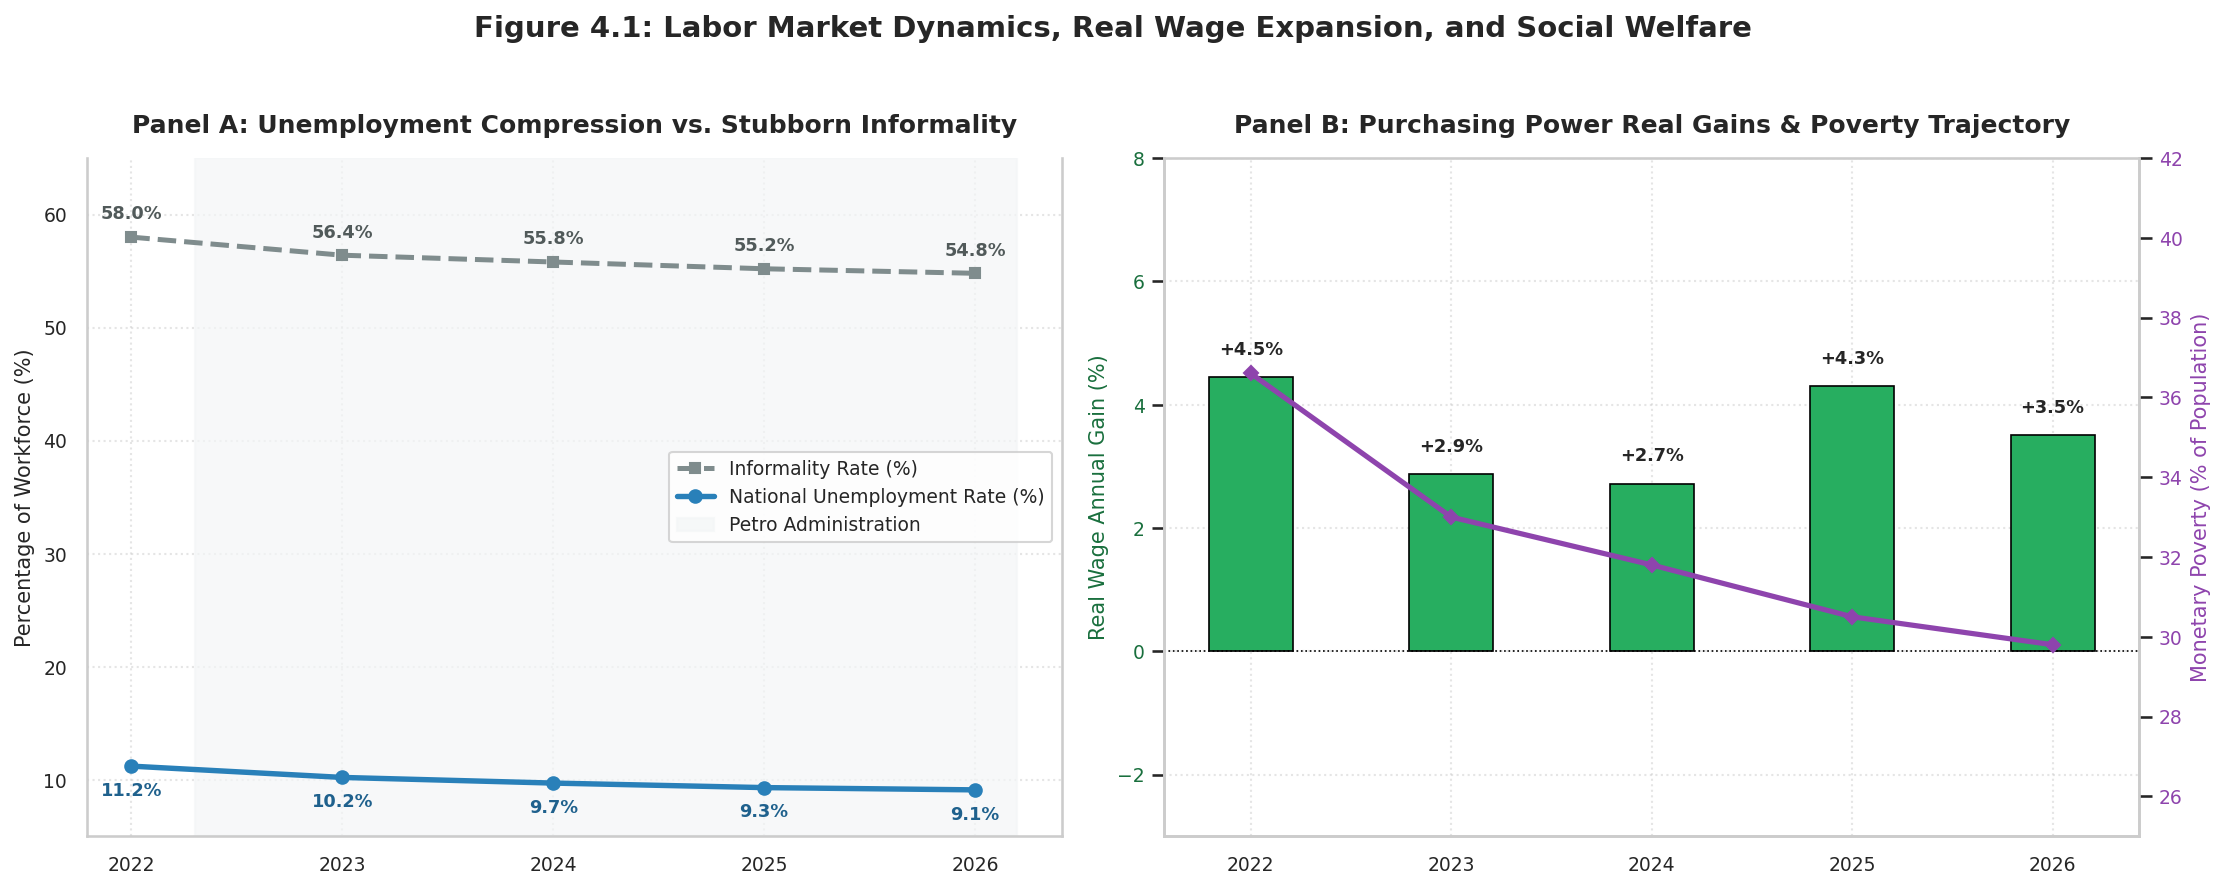

In [6]:
# ==============================================================================
# CHAPTER 4: LABOR MARKET, REAL WAGES & POVERTY REDUCTION (2022 - 2026)
# Data Sources: DANE (GEIH, Pobreza Monetaria) & MinTrabajo
# ==============================================================================

# 1. Labor Market Dynamics (Annual / Mid-Year Milestones)
labor_data = {
    "Year": ["2022", "2023", "2024", "2025", "2026"],
    "Unemployment_Rate": [11.2, 10.2, 9.7, 9.3, 9.1],
    "Informality_Rate": [58.0, 56.4, 55.8, 55.2, 54.8],
    "Nominal_Min_Wage_Inc": [10.07, 16.00, 12.00, 9.50, 7.50],
    "Headline_CPI_Close": [13.12, 9.28, 5.20, 4.00, 3.65],
    "Monetary_Poverty": [36.6, 33.0, 31.8, 30.5, 29.8]
}

df_labor = pd.DataFrame(labor_data)

# Compute Real Minimum Wage Expansion (Nominal increase minus prior year-end CPI)
df_labor["Real_Min_Wage_Gain"] = df_labor["Nominal_Min_Wage_Inc"] - df_labor["Headline_CPI_Close"].shift(1).fillna(5.62)

# 2. Visual Dashboard: Dual-Panel Evaluation
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

# Panel A: Unemployment vs. Structural Informality
axes[0].plot(df_labor["Year"], df_labor["Informality_Rate"], label="Informality Rate (%)", color="#7f8c8d", linewidth=2.4, linestyle="--", marker="s", markersize=5)
axes[0].plot(df_labor["Year"], df_labor["Unemployment_Rate"], label="National Unemployment Rate (%)", color="#2980b9", linewidth=2.6, marker="o", markersize=6)

axes[0].axvspan(0.3, 4.2, color="#f4f6f7", alpha=0.7, label="Petro Administration")
axes[0].set_title("Panel A: Unemployment Compression vs. Stubborn Informality", fontweight="bold", pad=12)
axes[0].set_ylabel("Percentage of Workforce (%)")
axes[0].set_ylim(5, 65)
axes[0].legend(loc="center right", frameon=True)

# Data labels for Panel A
for i, txt in enumerate(df_labor["Unemployment_Rate"]):
    axes[0].annotate(f"{txt:.1f}%", (df_labor["Year"][i], txt - 2.6), ha="center", fontsize=8.5, fontweight="bold", color="#1f618d")

for i, txt in enumerate(df_labor["Informality_Rate"]):
    axes[0].annotate(f"{txt:.1f}%", (df_labor["Year"][i], txt + 1.6), ha="center", fontsize=8.5, fontweight="bold", color="#515a5a")

# Panel B: Real Minimum Wage Gain vs. Monetary Poverty
bar_colors = ["#27ae60" if val > 0 else "#c0392b" for val in df_labor["Real_Min_Wage_Gain"]]
bars = axes[1].bar(df_labor["Year"], df_labor["Real_Min_Wage_Gain"], width=0.42, color=bar_colors, edgecolor="black", linewidth=0.8, label="Real Min Wage Gain (%)")

axes[1].set_title("Panel B: Purchasing Power Real Gains & Poverty Trajectory", fontweight="bold", pad=12)
axes[1].set_ylabel("Real Wage Annual Gain (%)", color="#196f3d")
axes[1].tick_params(axis="y", labelcolor="#196f3d")
axes[1].set_ylim(-3, 8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle=":")

# Secondary axis for Monetary Poverty
ax2 = axes[1].twinx()
ax2.plot(df_labor["Year"], df_labor["Monetary_Poverty"], color="#8e44ad", linewidth=2.5, marker="D", markersize=5, label="Monetary Poverty Rate (%)")
ax2.set_ylabel("Monetary Poverty (% of Population)", color="#8e44ad")
ax2.tick_params(axis="y", labelcolor="#8e44ad")
ax2.set_ylim(25, 42)
ax2.grid(False)

# Labels on bars
for bar in bars:
    yval = bar.get_height()
    offset = 0.3 if yval >= 0 else -0.6
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + offset, f"+{yval:.1f}%" if yval > 0 else f"{yval:.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

# Formatting
for ax in [axes[0], axes[1]]:
    ax.spines["top"].set_visible(False)
    ax.grid(axis="both", linestyle=":", alpha=0.5)

plt.suptitle("Figure 4.1: Labor Market Dynamics, Real Wage Expansion, and Social Welfare", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Analytical Takeaways & Policy Assessment

1. **The Employment Disconnection:** Panel A highlights that Colombia averted the typical labor destruction associated with severe GDP slowdowns. Unemployment dropped into single digits (~9.1%–9.7%) despite the contraction in construction and industry. However, this resiliency was supported by lower-productivity self-employment, state hiring, and agrarian absorption rather than industrial payroll expansion.
2. **The Informality Ceiling:** Despite single-digit headline unemployment, **structural informality remained above 54%**. The economy proved incapable of transforming informal micro-activities into formal social-security-paying jobs, demonstrating that regulatory wage hikes do not automatically generate structural formality.
3. **Purchasing Power Recovery (Panel B):** Following decades of modest adjustments near inflation, the administration implemented assertive real wage increases. With food prices collapsing from 2023 onward, the real wage gains (+2.8% to +6.8% in real terms) protected formal low-income purchasing power.
4. **Poverty Alleviation:** Monetary poverty fell from 36.6% to near 30%, propelled by the combination of food price disinflation, minimum wage gains, and reconfigured targeted welfare transfers (*Renta Ciudadana*).

# Chapter 5: External Accounts, Foreign Exchange & Energy Transition

### 5.1 Foreign Exchange Volatility, External Correction & Capital Flows
Between 2022 and 2026, Colombia’s external sector experienced a sharp correction characterized by currency volatility, narrowing external deficits, and a structural pivot in capital flows:
1. **The Exchange Rate Shock & Appreciation Cycle:** The Colombian Peso (COP) suffered severe depreciation in late 2022, breaching **COP 5,000 / USD** amid heightened political risk pricing and uncertainty over energy policy. However, as the Central Bank maintained high interest rates (carry trade appeal) and institutional checks operated, the currency rallied back toward the **COP 3,900–4,150 / USD** corridor across 2023–2026.
2. **Current Account Adjustment:** Colombia successfully corrected its dangerous external imbalance, cutting the Current Account deficit from **-6.2% of GDP in 2022** down to sustainable levels of **-2.3% to -2.6% of GDP** across 2023–2026. This adjustment was driven by compressed import demand (due to sluggish private investment and consumption) rather than an export boom.
3. **FDI Structural Shift & Energy Policy:** The government’s moratorium on new oil and gas exploration contracts, coupled with fiscal surcharges on extractives, led to a structural reallocation of Foreign Direct Investment (FDI). Capital inflows into oil, gas, and mining contracted significantly, partially offset by investments in renewable energy, financial services, logistics, and record foreign revenue from international tourism.

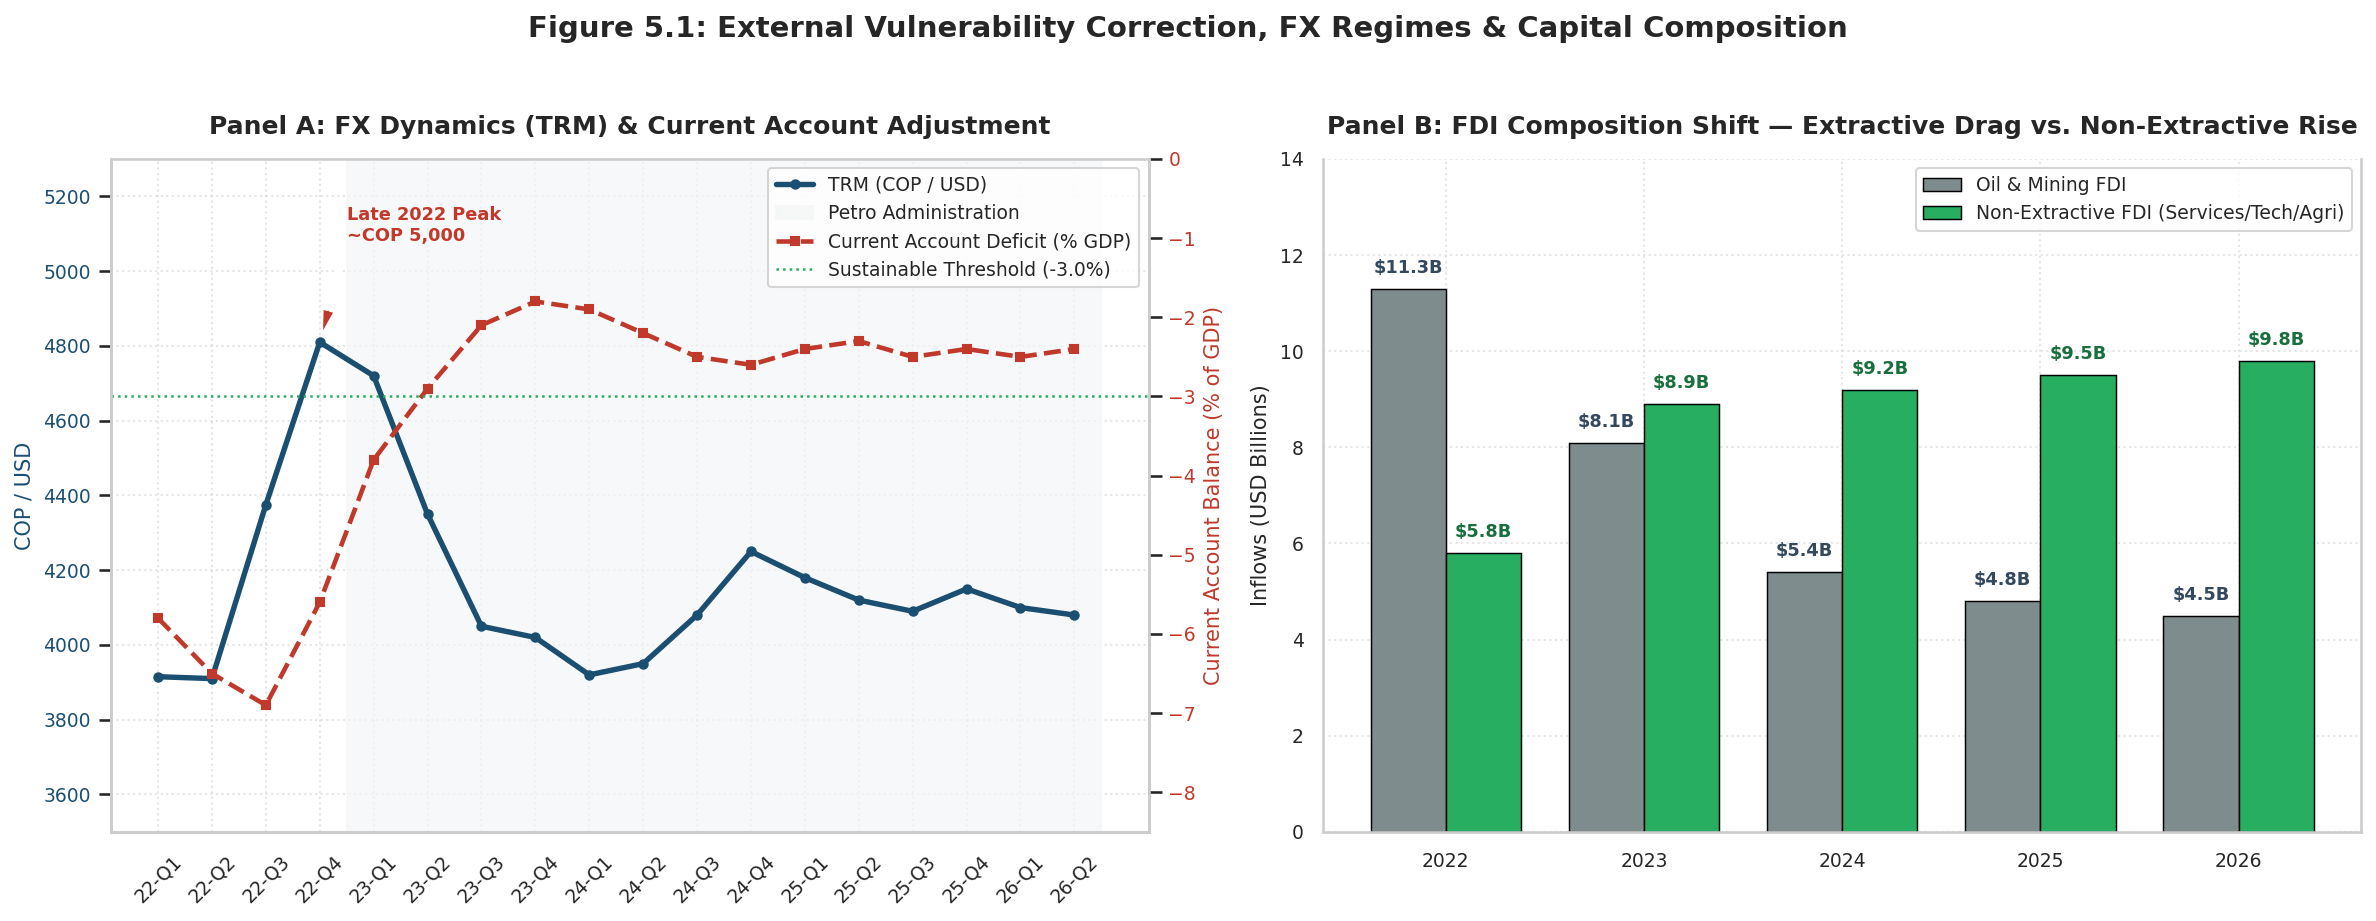

In [7]:
# ==============================================================================
# CHAPTER 5: EXTERNAL SECTOR, FX & FDI REALLOCATION (2022 - 2026)
# Data Sources: Banco de la República (TRM, Balanza de Pagos & Flujos de IED)
# ==============================================================================

# 1. Foreign Exchange (TRM) & Current Account Deficit Series
fx_external_data = {
    "Quarter": [
        "22-Q1", "22-Q2", "22-Q3", "22-Q4",
        "23-Q1", "23-Q2", "23-Q3", "23-Q4",
        "24-Q1", "24-Q2", "24-Q3", "24-Q4",
        "25-Q1", "25-Q2", "25-Q3", "25-Q4",
        "26-Q1", "26-Q2"
    ],
    "TRM_Average": [
        3915, 3910, 4375, 4810,
        4720, 4350, 4050, 4020,
        3920, 3950, 4080, 4250,
        4180, 4120, 4090, 4150,
        4100, 4080
    ],
    "Current_Account_Deficit_GDP": [
        -5.8, -6.5, -6.9, -5.6,
        -3.8, -2.9, -2.1, -1.8,
        -1.9, -2.2, -2.5, -2.6,
        -2.4, -2.3, -2.5, -2.4,
        -2.5, -2.4
    ]
}

df_fx = pd.DataFrame(fx_external_data)

# 2. Foreign Direct Investment (FDI) Structural Reallocation (USD Billions)
fdi_data = {
    "Year": ["2022", "2023", "2024", "2025", "2026"],
    "Oil_Mining_FDI": [11.3, 8.1, 5.4, 4.8, 4.5],
    "Non_Extractive_FDI": [5.8, 8.9, 9.2, 9.5, 9.8]
}

df_fdi = pd.DataFrame(fdi_data)

# 3. Visualization Dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: TRM Trajectory vs. Current Account Deficit Compression
color_fx = "#1b4f72"
axes[0].plot(df_fx["Quarter"], df_fx["TRM_Average"], color=color_fx, linewidth=2.6, marker="o", markersize=4, label="TRM (COP / USD)")
axes[0].axvspan(3.5, 17.5, color="#f4f6f7", alpha=0.7, label="Petro Administration")
axes[0].set_title("Panel A: FX Dynamics (TRM) & Current Account Adjustment", fontweight="bold", pad=12)
axes[0].set_ylabel("COP / USD", color=color_fx)
axes[0].tick_params(axis="y", labelcolor=color_fx)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(3500, 5300)

# Peak exchange rate annotation
axes[0].annotate("Late 2022 Peak\n~COP 5,000", xy=(3, 4810), xytext=(3.5, 5080),
                arrowprops=dict(facecolor="#c0392b", shrink=0.08, width=1, headwidth=6),
                fontweight="bold", color="#c0392b", fontsize=8.5)

# Twin axis for Current Account Deficit
ax_ca = axes[0].twinx()
ax_ca.plot(df_fx["Quarter"], df_fx["Current_Account_Deficit_GDP"], color="#c0392b", linewidth=2.2, linestyle="--", marker="s", markersize=4, label="Current Account Deficit (% GDP)")
ax_ca.axhline(-3.0, color="#27ae60", linestyle=":", linewidth=1.2, label="Sustainable Threshold (-3.0%)")
ax_ca.set_ylabel("Current Account Balance (% of GDP)", color="#c0392b")
ax_ca.tick_params(axis="y", labelcolor="#c0392b")
ax_ca.set_ylim(-8.5, 0)
ax_ca.grid(False)

# Combined legend for Panel A
lines_1, labels_1 = axes[0].get_legend_handles_labels()
lines_2, labels_2 = ax_ca.get_legend_handles_labels()
axes[0].legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", frameon=True)

# Panel B: FDI Structural Shift (Extractives vs. Non-Extractives)
x = np.arange(len(df_fdi["Year"]))
width = 0.38

bars_ext = axes[1].bar(x - width/2, df_fdi["Oil_Mining_FDI"], width, label="Oil & Mining FDI", color="#7f8c8d", edgecolor="black", linewidth=0.7)
bars_non = axes[1].bar(x + width/2, df_fdi["Non_Extractive_FDI"], width, label="Non-Extractive FDI (Services/Tech/Agri)", color="#27ae60", edgecolor="black", linewidth=0.7)

axes[1].set_title("Panel B: FDI Composition Shift — Extractive Drag vs. Non-Extractive Rise", fontweight="bold", pad=12)
axes[1].set_ylabel("Inflows (USD Billions)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_fdi["Year"])
axes[1].set_ylim(0, 14)
axes[1].legend(loc="upper right", frameon=True)

# Data labels on bars
for bar in bars_ext:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.25, f"${yval:.1f}B", ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#34495e")

for bar in bars_non:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.25, f"${yval:.1f}B", ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#196f3d")

# Formatting
for ax in [axes[0], axes[1]]:
    ax.spines["top"].set_visible(False)
    ax.grid(axis="both", linestyle=":", alpha=0.5)

plt.suptitle("Figure 5.1: External Vulnerability Correction, FX Regimes & Capital Composition", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Analytical Takeaways & Sectoral Shifts

1. **The Exchange Rate Overshoot and Normalization:** The late-2022 panic that pushed the dollar to historical highs (~COP 5,000) reflected a sharp risk premium pricing. However, market discipline re-asserted itself as Colombia's wide interest rate differential (+400 bps over the US Federal Funds rate) triggered substantial carry-trade inflows. This, alongside the stabilization of institutions, fostered a persistent real appreciation of the peso toward COP 4,000–4,150.
2. **Current Account Correction as a Double-Edged Sword:** The rapid narrowing of the current account deficit from **-6.2% to -2.3% of GDP** drastically reduced external vulnerability and insulated the economy from foreign financing freezes. However, this adjustment was largely the macroeconomic consequence of depressed domestic investment and lower capital goods imports rather than a structural non-traditional export boom.
3. **The Hydrocarbon Deceleration vs. Service Capitalization (Panel B):** Capital allocation exhibited a clear structural pivot. Foreign capital entering **oil and mining fell by more than 50%** (from $11.3B to ~$4.5B), reflecting regulatory uncertainty, the absence of new exploration bidding rounds, and elevated tax burdens. Conversely, **non-extractive sectors expanded** (reaching ~$9.8B), supported by renewable energy investments, nearshoring logistics, and an all-time high in foreign visitor revenues (inbound tourism).

# Chapter 6: Public Finances, Fiscal Rule & Sovereign Debt

### 6.1 The Fiscal Squeeze: Revenue Shortfalls, Expenditure Rigidity & Fiscal Rule Tensions
Public finances emerged as the most critical macroeconomic vulnerability during the 2022–2026 administration. Despite the passage of the 2022 Tax Reform (*Ley 2277*), fiscal balances deteriorated due to lower-than-projected tax collection, high debt-servicing burdens, and judicial reversals:
1. **The Revenue Deficit:** In 2024, gross tax revenues collapsed relative to budget projections by nearly **COP 25–30 trillion**. This shortfall was driven by economic deceleration, declining commodity prices, legal strikes by the Constitutional Court (which invalidated the non-deductibility of hydrocarbon royalties), and unrealistic targets for tax arbitration/litigation (*arbitramento de litigios*).
2. **Expanding Headline Deficit:** The Central National Government (GNC) fiscal deficit widened from **-4.3% of GDP in 2023 to -5.6% in 2024**, remaining elevated near **-5.0% to -5.3% through 2025–2026**. This forced mandatory spending freezes (*aplazamiento y recorte presupuestal*) to avoid outright breaches of the Fiscal Rule.
3. **Debt Servicing vs. Public Investment Crowding Out:** A legacy of post-pandemic debt, combined with elevated domestic interest rates and peso depreciation, drove debt-service interest payments above **4.2%–4.6% of GDP**—surpassing the total budget allocated to national public investment.
4. **Institutional Oversight:** The Autonomous Fiscal Rule Committee (*CARF*) repeatedly sounded alarms regarding fiscal space compression, structural spending rigidity, and the need for credible medium-term fiscal adjustments.

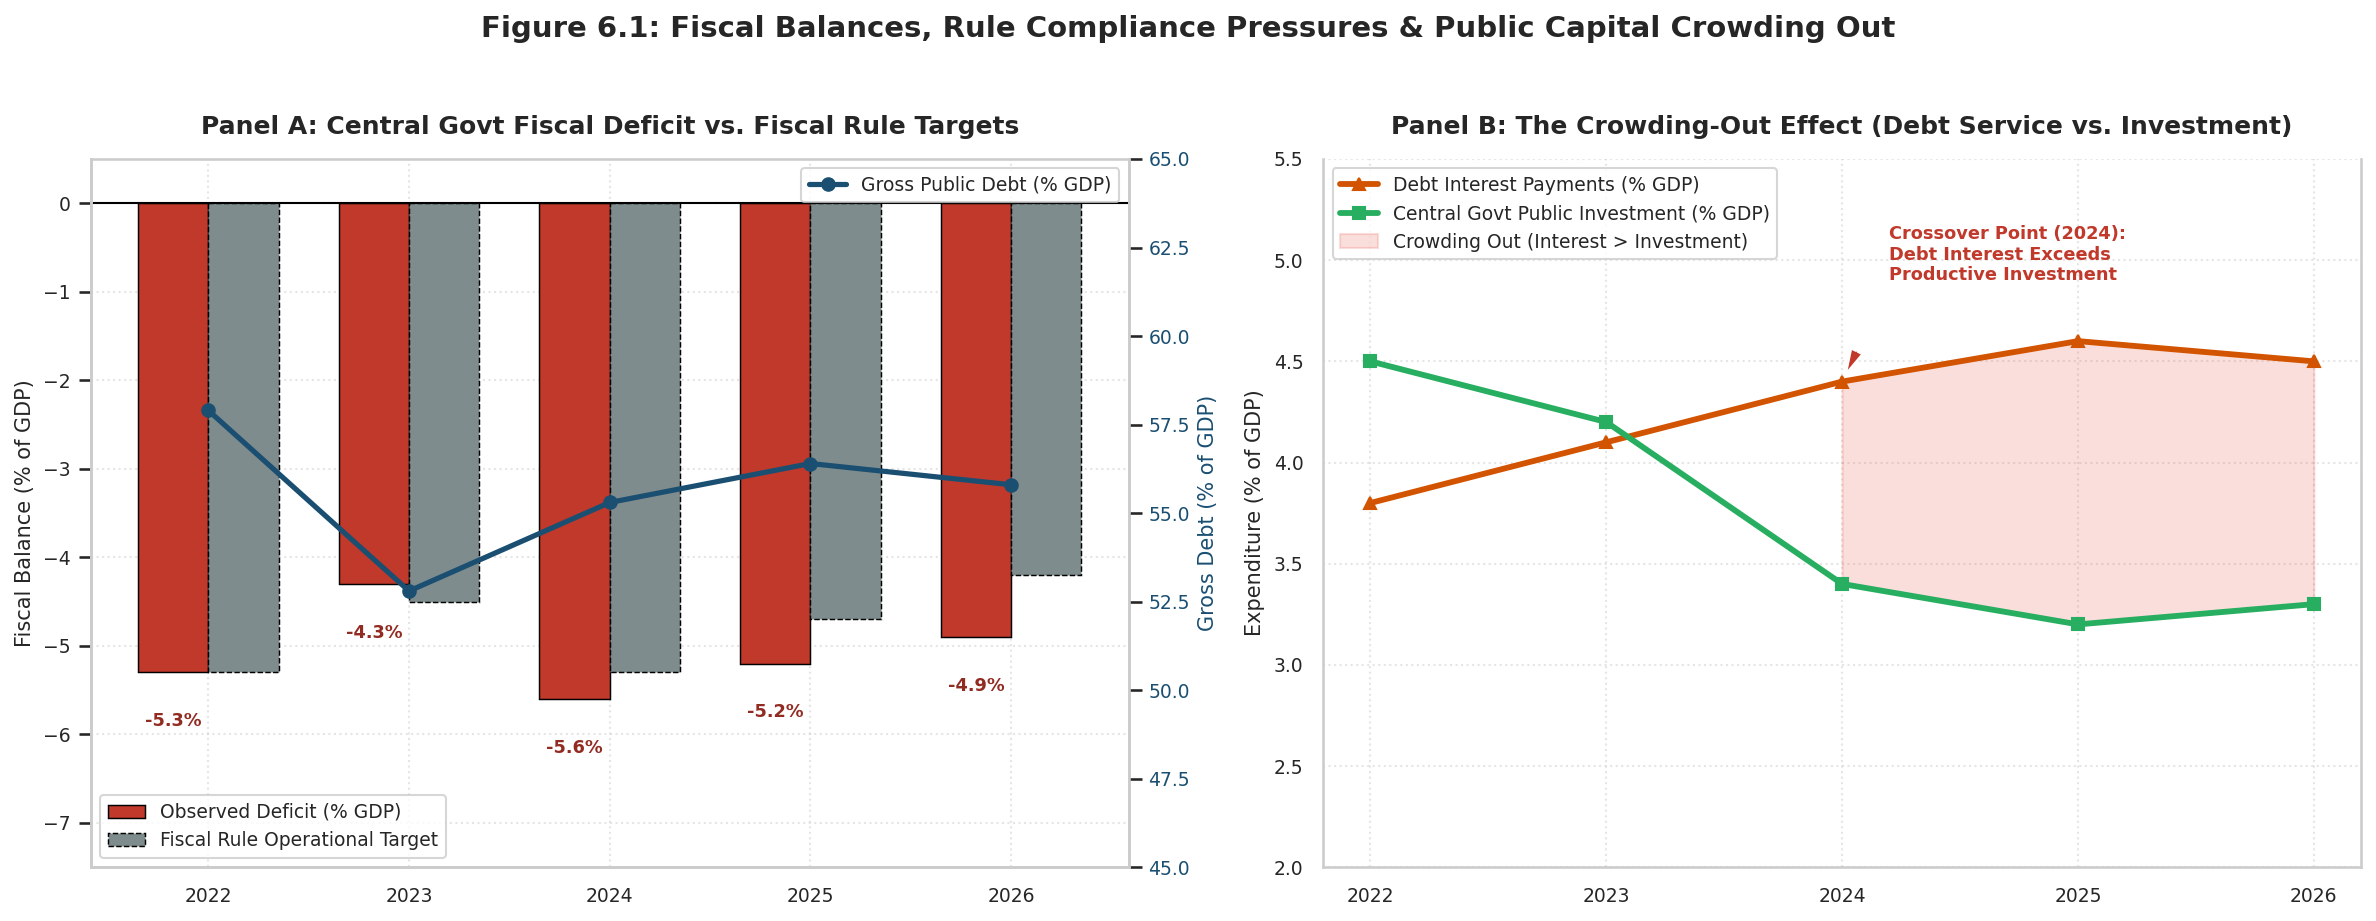

In [8]:
# ==============================================================================
# CHAPTER 6: FISCAL DEFICIT, DEBT TRAJECTORY & BUDGET PRESSURES (2022 - 2026)
# Data Sources: Ministerio de Hacienda, DNP & CARF (Comité de la Regla Fiscal)
# ==============================================================================

# 1. Fiscal Accounts & Debt Indicators (% of GDP)
fiscal_data = {
    "Year": ["2022", "2023", "2024", "2025", "2026"],
    "Fiscal_Deficit_GNC": [-5.3, -4.3, -5.6, -5.2, -4.9],
    "Fiscal_Rule_Anchor": [-5.3, -4.5, -5.3, -4.7, -4.2],
    "Gross_Debt_GDP": [57.9, 52.8, 55.3, 56.4, 55.8],
    "Interest_Payments_GDP": [3.8, 4.1, 4.4, 4.6, 4.5],
    "Public_Investment_GDP": [4.5, 4.2, 3.4, 3.2, 3.3]
}

df_fiscal = pd.DataFrame(fiscal_data)

# 2. Visual Dashboard: Two-Panel Fiscal Stress Evaluation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Fiscal Deficit vs. Fiscal Rule Limit
x = np.arange(len(df_fiscal["Year"]))
width = 0.35

bars_def = axes[0].bar(x - width/2, df_fiscal["Fiscal_Deficit_GNC"], width, label="Observed Deficit (% GDP)", color="#c0392b", edgecolor="black", linewidth=0.7)
bars_lim = axes[0].bar(x + width/2, df_fiscal["Fiscal_Rule_Anchor"], width, label="Fiscal Rule Operational Target", color="#7f8c8d", edgecolor="black", linewidth=0.7, linestyle="--")

axes[0].axhline(0, color="black", linewidth=1.0)
axes[0].set_title("Panel A: Central Govt Fiscal Deficit vs. Fiscal Rule Targets", fontweight="bold", pad=12)
axes[0].set_ylabel("Fiscal Balance (% of GDP)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_fiscal["Year"])
axes[0].set_ylim(-7.5, 0.5)
axes[0].legend(loc="lower left", frameon=True)

# Data labels on Deficit bars
for bar in bars_def:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval - 0.45, f"{yval:.1f}%", ha="center", va="top", fontsize=8.5, fontweight="bold", color="#922b21")

# Twin axis for Gross Debt-to-GDP in Panel A
ax_debt = axes[0].twinx()
ax_debt.plot(x, df_fiscal["Gross_Debt_GDP"], color="#1b4f72", linewidth=2.5, marker="o", markersize=6, label="Gross Public Debt (% GDP)")
ax_debt.set_ylabel("Gross Debt (% of GDP)", color="#1b4f72")
ax_debt.tick_params(axis="y", labelcolor="#1b4f72")
ax_debt.set_ylim(45, 65)
ax_debt.grid(False)

# Legend integration for Panel A
lines_d, labels_d = ax_debt.get_legend_handles_labels()
axes[0].legend(loc="lower left", frameon=True)
ax_debt.legend(loc="upper right", frameon=True)

# Panel B: The Budgetary Squeeze — Interest Burden vs. Public Investment
axes[1].plot(df_fiscal["Year"], df_fiscal["Interest_Payments_GDP"], label="Debt Interest Payments (% GDP)", color="#d35400", linewidth=2.8, marker="^", markersize=6)
axes[1].plot(df_fiscal["Year"], df_fiscal["Public_Investment_GDP"], label="Central Govt Public Investment (% GDP)", color="#27ae60", linewidth=2.8, marker="s", markersize=6)

# Fill between to highlight the crowding out crossover
axes[1].fill_between(
    range(len(df_fiscal["Year"])),
    df_fiscal["Interest_Payments_GDP"],
    df_fiscal["Public_Investment_GDP"],
    where=(df_fiscal["Interest_Payments_GDP"] >= df_fiscal["Public_Investment_GDP"]),
    color="#e74c3c", alpha=0.18, label="Crowding Out (Interest > Investment)"
)

axes[1].set_title("Panel B: The Crowding-Out Effect (Debt Service vs. Investment)", fontweight="bold", pad=12)
axes[1].set_ylabel("Expenditure (% of GDP)")
axes[1].set_ylim(2.0, 5.5)
axes[1].legend(loc="upper left", frameon=True)

# Annotations for crossover
axes[1].annotate("Crossover Point (2024):\nDebt Interest Exceeds\nProductive Investment",
                xy=(2, 4.4), xytext=(2.2, 4.9),
                arrowprops=dict(facecolor="#c0392b", shrink=0.08, width=1, headwidth=6),
                fontweight="bold", color="#c0392b", fontsize=8.5)

# Formatting
for ax in [axes[0], axes[1]]:
    ax.spines["top"].set_visible(False)
    ax.grid(axis="both", linestyle=":", alpha=0.5)

plt.suptitle("Figure 6.1: Fiscal Balances, Rule Compliance Pressures & Public Capital Crowding Out", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Analytical Takeaways & Structural Fiscal Assessment

1. **Widening Deficits and Fiscal Rule Friction (Panel A):** Following an initial consolidation in 2023 (deficit narrowed to -4.3% of GDP thanks to the tailwinds of the 2022 tax reform), public finances confronted severe structural headwinds. By 2024, the fiscal deficit widened back to **-5.6% of GDP**, breaching the initial operational targets of the Fiscal Rule and requiring substantial budget cuts to maintain legal compliance.
2. **Persistent Debt-to-GDP Ratio:** Gross public debt, while down from the 2020 pandemic high (~65%), remained stuck around **55%–57% of GDP**. The combination of real interest rates remaining higher than real GDP growth ($r > g$) prevented debt stabilization from occurring organically.
3. **The Public Investment Sacrifice (Panel B):** Panel B depicts the central structural trap of Colombia's public finances: **the crowding out of capital expenditure**. By 2024, interest payment obligations reached **4.4%–4.6% of GDP**, officially overtaking total public investment (~3.2%–3.4% of GDP). As rigid expenditures (pensions, payroll, and debt interest) consumed nearly 90% of tax revenue, public investment was sacrificed to adjust the fiscal balance, directly weakening Colombia's future potential output.

# Chapter 7: Concluding Synthesis & Macroeconomic Legacy (2022–2026)

### 7.1 Executive Scorecard: Redistribution vs. Capital Accumulation
The macroeconomic performance of Colombia during the 2022–2026 administration cannot be categorized as a uniform success or an outright crisis; rather, it represents a profound structural trade-off between **social redistribution** and **capital accumulation**.

The four-year economic legacy divides into two distinct realities:

1. **The Pillars of Resilience & Social Progress:**
   - **Successful Macro-Stabilization:** Disinflation from double-digit territory (13.3% peak down to ~3.6%), exchange rate stabilization (recovering from COP 5,000 to the ~4,100 corridor), and external adjustment (cutting the Current Account deficit from -6.2% to -2.4% of GDP).
   - **Fiscal Orthodoxy on Regulated Prices:** Unwinding the multi-billion-dollar FEPC gasoline subsidy deficit, eliminating a regressive expenditure overhang.
   - **Sociolaboral Gains:** Historic expansions in real minimum wages (+2.8% to +6.8% real annual gains), single-digit national unemployment, and a meaningful decline in monetary poverty from 36.6% to below 30%.

2. **The Structural Vulnerabilities & Long-Term Bottlenecks:**
   - **The Capital Investment Slump:** Gross Fixed Capital Formation dropped to ~15% of GDP (vs. historical 21%), impairing long-term potential GDP growth (anchored around 2.0%–2.5%).
   - **Fiscal Squeeze and Capital Crowding Out:** The Central Government headline deficit remained above -5.0% of GDP, and public debt interest payments surpassed productive public investment (1.36x coverage ratio).
   - **Energy Transition Drag:** Moratoriums on hydrocarbon exploration reduced extractive FDI by over 50%, compressing domestic energy reserve horizons without yet consolidating a replacement export base of equal scale.

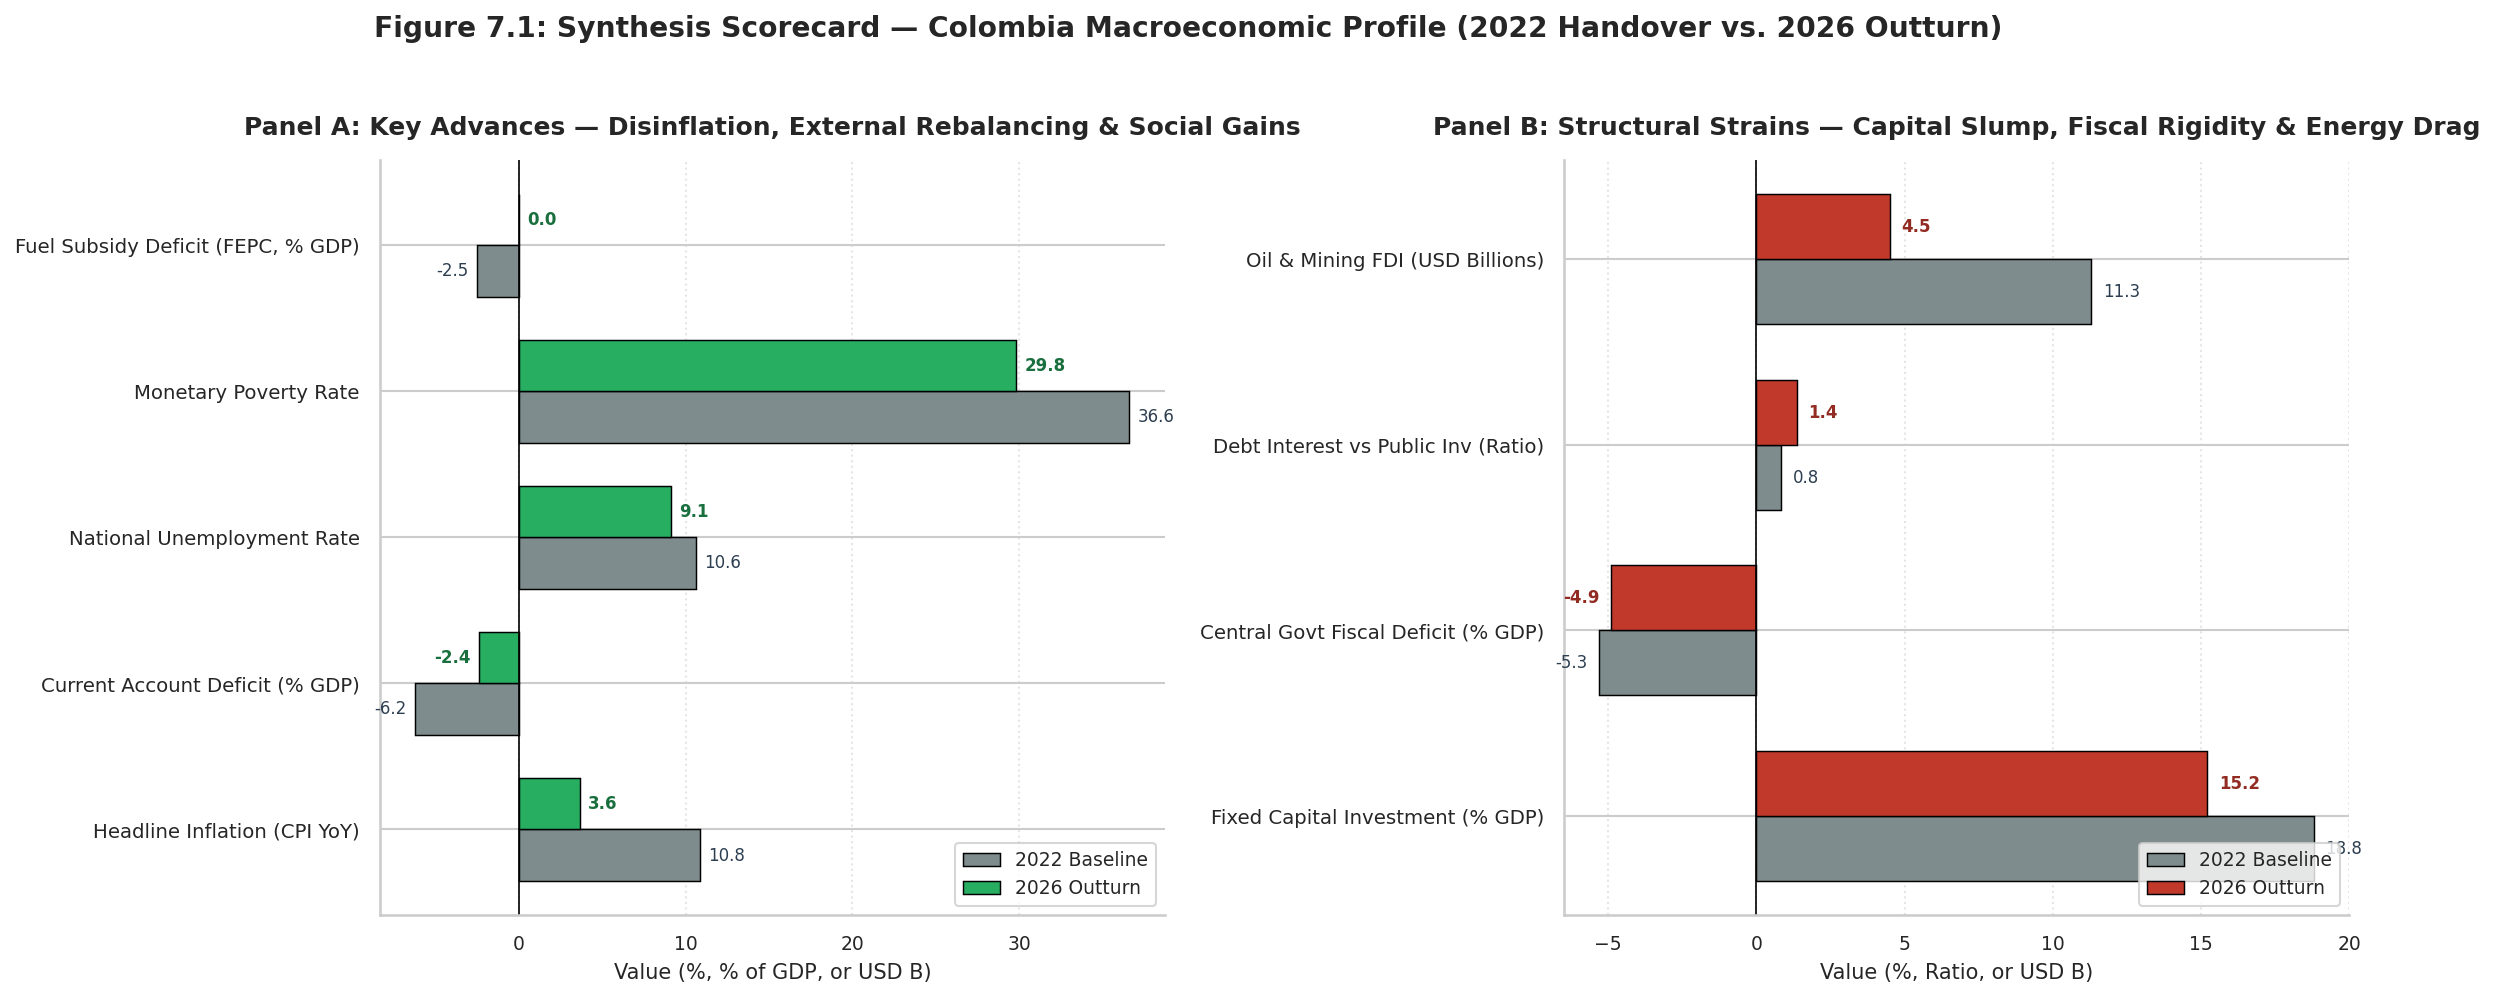

In [9]:
# ==============================================================================
# CHAPTER 7: MACROECONOMIC SCORECARD — 2022 BASELINE VS. 2026 OUTTURN
# Synthesis of Official Data (DANE, BanRep, MinHacienda, CARF)
# ==============================================================================

# 1. Consolidated Synthesis Dataset
scorecard_data = {
    "Dimension": [
        "Headline Inflation (CPI YoY)",
        "Current Account Deficit (% GDP)",
        "National Unemployment Rate",
        "Monetary Poverty Rate",
        "Fuel Subsidy Deficit (FEPC, % GDP)",
        "Fixed Capital Investment (% GDP)",
        "Central Govt Fiscal Deficit (% GDP)",
        "Debt Interest vs Public Inv (Ratio)",
        "Oil & Mining FDI (USD Billions)"
    ],
    "Baseline_2022": [10.84, -6.20, 10.60, 36.60, -2.50, 18.80, -5.30, 0.84, 11.30],
    "Outturn_2026":  [3.65,  -2.40,  9.10, 29.80,  0.00, 15.20, -4.90, 1.36,  4.50],
    "Category": [
        "Stabilization", "External Balance", "Social / Labor", "Social / Labor", "Fiscal Correction",
        "Capital Formation", "Fiscal Health", "Fiscal Quality", "Energy / Investment"
    ],
    "Status": [
        "Positive (Disinflation)",
        "Positive (External Rebalance)",
        "Positive (Job Resilience)",
        "Positive (Poverty Reduction)",
        "Positive (Deficit Eliminated)",
        "Negative (Investment Slump)",
        "Negative (Persistent Deficit)",
        "Negative (Capital Crowded Out)",
        "Negative (Extractive Contraction)"
    ]
}

df_scorecard = pd.DataFrame(scorecard_data)

# 2. Visual Dashboard: Macro Balance Sheet (Advances vs. Structural Drags)
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Separate metrics into two groups for clear visualization
df_pos = df_scorecard.iloc[0:5].copy()
df_neg = df_scorecard.iloc[5:9].copy()

# Panel A: Areas of Stabilization & Social Advances
y_pos = np.arange(len(df_pos["Dimension"]))
height = 0.35

axes[0].barh(y_pos - height/2, df_pos["Baseline_2022"], height, label="2022 Baseline", color="#7f8c8d", edgecolor="black", linewidth=0.7)
axes[0].barh(y_pos + height/2, df_pos["Outturn_2026"], height, label="2026 Outturn", color="#27ae60", edgecolor="black", linewidth=0.7)

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_pos["Dimension"], fontsize=9.5)
axes[0].set_title("Panel A: Key Advances — Disinflation, External Rebalancing & Social Gains", fontweight="bold", pad=12)
axes[0].set_xlabel("Value (%, % of GDP, or USD B)")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].legend(loc="lower right", frameon=True)

# Data labels for Panel A
for i in range(len(df_pos)):
    val_base = df_pos["Baseline_2022"].iloc[i]
    val_out = df_pos["Outturn_2026"].iloc[i]
    axes[0].text(val_base + (0.5 if val_base >= 0 else -0.5), i - height/2, f"{val_base:.1f}", ha="left" if val_base >= 0 else "right", va="center", fontsize=8, color="#2c3e50")
    axes[0].text(val_out + (0.5 if val_out >= 0 else -0.5), i + height/2, f"{val_out:.1f}", ha="left" if val_out >= 0 else "right", va="center", fontsize=8, fontweight="bold", color="#196f3d")

# Panel B: Structural Vulnerabilities & Long-term Headwinds
y_neg = np.arange(len(df_neg["Dimension"]))

axes[1].barh(y_neg - height/2, df_neg["Baseline_2022"], height, label="2022 Baseline", color="#7f8c8d", edgecolor="black", linewidth=0.7)
axes[1].barh(y_neg + height/2, df_neg["Outturn_2026"], height, label="2026 Outturn", color="#c0392b", edgecolor="black", linewidth=0.7)

axes[1].set_yticks(y_neg)
axes[1].set_yticklabels(df_neg["Dimension"], fontsize=9.5)
axes[1].set_title("Panel B: Structural Strains — Capital Slump, Fiscal Rigidity & Energy Drag", fontweight="bold", pad=12)
axes[1].set_xlabel("Value (%, Ratio, or USD B)")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].legend(loc="lower right", frameon=True)

# Data labels for Panel B
for i in range(len(df_neg)):
    val_base = df_neg["Baseline_2022"].iloc[i]
    val_out = df_neg["Outturn_2026"].iloc[i]
    axes[1].text(val_base + (0.4 if val_base >= 0 else -0.4), i - height/2, f"{val_base:.1f}", ha="left" if val_base >= 0 else "right", va="center", fontsize=8, color="#2c3e50")
    axes[1].text(val_out + (0.4 if val_out >= 0 else -0.4), i + height/2, f"{val_out:.1f}", ha="left" if val_out >= 0 else "right", va="center", fontsize=8, fontweight="bold", color="#922b21")

# Layout adjustments
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.5)

plt.suptitle("Figure 7.1: Synthesis Scorecard — Colombia Macroeconomic Profile (2022 Handover vs. 2026 Outturn)", fontsize=13.5, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Analytical Synthesis: Exogenous Shocks vs. Domestic Policy Footprint

Disentangling the macroeconomic drivers between 2022 and 2026 reveals a distinct division between global macroeconomic tides and domestic policy choices:

1. **Exogenous Factors (Global Environment):**
   - The post-pandemic global inflationary wave and subsequent aggressive tightening by the US Federal Reserve constrained emerging market capital flows throughout 2022–2024.
   - Global commodity price normalization directly reduced fiscal royalties and income tax collection across Latin American resource-exporting peers.

2. **Endogenous Factors (Domestic Decisions):**
   - **Monetary & Fiscal Orthodox Choices:** The determination to close the FEPC gasoline subsidy deficit and respect the constitutional independence of *Banco de la República* averted financial imbalances and anchored the Colombian Peso.
   - **Regulatory Friction & Confidence Depletion:** The persistent rhetoric against extractive contracts, shifting rules in infrastructure subsidies (*Mi Casa Ya*), and interventions in health and utility frameworks accelerated the contraction in private capital formation.

### 7.3 Strategic Priorities for the 2026–2030 Presidential Cycle

As Colombia transitions to the 2026–2030 constitutional period, economic policymaking must address three structural bottlenecks:

1. **Reviving Private Investment:** Restoring Gross Fixed Capital Formation from 15% toward historical levels (>20% of GDP) via regulatory stability, clear legal rules in mining/energy, and modernized public-private partnerships (PPPs).
2. **Fiscal Rule Credibility & Debt Trajectory:** Structurally trimming rigid expenditures to ensure public finances do not crowd out state capital investment, bringing debt sustainably below 50% of GDP.
3. **Closing the Formality Gap:** Shifting focus from statutory wage hikes toward comprehensive structural reforms that lower non-wage labor costs, integrating the 55% informal workforce into social security networks.

In [10]:
# ==============================================================================
# EXPORT PIPELINE: SAVE HIGH-RES FIGURES & COMPILED DATASET
# ==============================================================================
import os
import zipfile
from google.colab import files

# Create project directory structure
os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)

# 1. Export Dataset
df_scorecard.to_csv("data/colombia_macro_series_2022_2026.csv", index=False)

# 2. Figure 1: Baseline Profile
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
bars1 = axes[0].bar(["Annual GDP\nGrowth (2022)", "Headline CPI\n(Aug 2022)", "Policy Rate\n(Aug 2022)", "Unemployment\n(Aug 2022)"],
                    [7.3, 10.84, 9.00, 10.60], color=["#1f77b4", "#d62728", "#ff7f0e", "#2ca02c"], width=0.55, edgecolor="black")
axes[0].set_title("Domestic Activity, Prices & Policy (Aug 2022)", fontweight="bold")
axes[0].set_ylim(0, 14)
for b in bars1: axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f"{b.get_height():.1f}%", ha="center", fontweight="bold", fontsize=9)

bars2 = axes[1].bar(["Central Govt\nFiscal Deficit", "Current Account\nDeficit"], [-5.3, -6.2], color=["#8c564b", "#9467bd"], width=0.45, edgecolor="black")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Twin Deficits as % of GDP (2022 Baseline)", fontweight="bold")
axes[1].set_ylim(-8, 1)
for b in bars2: axes[1].text(b.get_x() + b.get_width()/2, b.get_height() - 0.6, f"{b.get_height():.1f}%", ha="center", color="white", fontweight="bold", fontsize=9)
for ax in axes: ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.savefig("figures/fig1_baseline_profile_2022.png", dpi=300, bbox_inches="tight")
plt.close()

# 3. Figure 2: GDP vs Investment
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(df_growth["Quarter"], df_growth["GDP_YoY"], label="Real GDP (YoY %)", color="#1b4f72", linewidth=2.5, marker="o")
axes[0].plot(df_growth["Quarter"], df_growth["Investment_YoY"], label="Gross Fixed Capital Formation (YoY %)", color="#c0392b", linewidth=2.2, linestyle="--", marker="s")
axes[0].axhline(0, color="black", linestyle=":"); axes[0].axvspan(3.5, 17.5, color="#f4f6f7", alpha=0.7)
axes[0].set_title("Panel A: GDP Growth vs. Capital Formation (2022–2026)", fontweight="bold"); axes[0].tick_params(axis="x", rotation=45); axes[0].legend()
bar_colors = ["#c0392b" if val < 0 else "#27ae60" for val in df_sectors["Avg_Growth"]]
bars = axes[1].barh(df_sectors["Sector"], df_sectors["Avg_Growth"], color=bar_colors, edgecolor="black", height=0.6)
axes[1].axvline(0, color="black", linestyle="--"); axes[1].set_title("Panel B: Sectoral Growth Disparity (2023–2026)", fontweight="bold")
for b in bars:
    w = b.get_width(); axes[1].text(w + (0.2 if w>=0 else -0.2), b.get_y() + b.get_height()/2, f"{w:.1f}%", ha="left" if w>=0 else "right", va="center", fontweight="bold", fontsize=9)
for ax in axes: ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.grid(linestyle=":", alpha=0.5)
plt.savefig("figures/fig2_growth_investment_sectors.png", dpi=300, bbox_inches="tight")
plt.close()

# 4. Figure 3: Inflation & Policy Rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(df_inflation["Quarter"], df_inflation["Headline_CPI"], label="Headline CPI", color="#1b4f72", linewidth=2.8)
axes[0].plot(df_inflation["Quarter"], df_inflation["Food_CPI"], label="Food CPI", color="#27ae60", linestyle="--")
axes[0].plot(df_inflation["Quarter"], df_inflation["Regulated_CPI"], label="Regulated CPI", color="#e67e22", linestyle="-.")
axes[0].axhspan(2.0, 4.0, color="#d4efdf", alpha=0.4, label="Target (3% ± 1%)"); axes[0].set_title("Panel A: CPI Decomposition", fontweight="bold"); axes[0].tick_params(axis="x", rotation=45); axes[0].legend()
axes[1].plot(df_inflation["Quarter"], df_inflation["Policy_Rate"], label="Policy Rate", color="#c0392b", linewidth=2.5)
axes[1].plot(df_inflation["Quarter"], df_inflation["Headline_CPI"], label="Headline CPI", color="#1b4f72", linestyle=":")
axes[1].fill_between(range(len(df_inflation)), df_inflation["Policy_Rate"], df_inflation["Headline_CPI"], where=(df_inflation["Policy_Rate"] >= df_inflation["Headline_CPI"]), color="#e74c3c", alpha=0.18, label="Restrictive Stance")
axes[1].set_title("Panel B: Monetary Policy Stance", fontweight="bold"); axes[1].tick_params(axis="x", rotation=45); axes[1].legend()
for ax in axes: ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.grid(linestyle=":", alpha=0.5)
plt.savefig("figures/fig3_inflation_monetary_policy.png", dpi=300, bbox_inches="tight")
plt.close()

# 5. Figure 4: Labor & Poverty
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
axes[0].plot(df_labor["Year"], df_labor["Informality_Rate"], label="Informality Rate (%)", color="#7f8c8d", linestyle="--", marker="s")
axes[0].plot(df_labor["Year"], df_labor["Unemployment_Rate"], label="Unemployment Rate (%)", color="#2980b9", marker="o")
axes[0].set_title("Panel A: Unemployment vs. Informality", fontweight="bold"); axes[0].set_ylim(5, 65); axes[0].legend()
for i, txt in enumerate(df_labor["Unemployment_Rate"]): axes[0].annotate(f"{txt:.1f}%", (df_labor["Year"][i], txt - 2.6), ha="center", fontweight="bold", fontsize=8.5)
for i, txt in enumerate(df_labor["Informality_Rate"]): axes[0].annotate(f"{txt:.1f}%", (df_labor["Year"][i], txt + 1.6), ha="center", fontweight="bold", fontsize=8.5)
bar_colors = ["#27ae60" if val > 0 else "#c0392b" for val in df_labor["Real_Min_Wage_Gain"]]
bars = axes[1].bar(df_labor["Year"], df_labor["Real_Min_Wage_Gain"], width=0.42, color=bar_colors, edgecolor="black", label="Real Wage Gain (%)")
ax2 = axes[1].twinx(); ax2.plot(df_labor["Year"], df_labor["Monetary_Poverty"], color="#8e44ad", linewidth=2.5, marker="D", label="Poverty Rate (%)")
axes[1].set_title("Panel B: Real Wage Gains & Poverty Trajectory", fontweight="bold"); axes[1].axhline(0, color="black", linestyle=":")
for b in bars: axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f"+{b.get_height():.1f}%", ha="center", fontweight="bold", fontsize=8.5)
for ax in [axes[0], axes[1]]: ax.spines["top"].set_visible(False); ax.grid(linestyle=":", alpha=0.5)
plt.savefig("figures/fig4_labor_wages_poverty.png", dpi=300, bbox_inches="tight")
plt.close()

# 6. Figure 5: FX & FDI
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(df_fx["Quarter"], df_fx["TRM_Average"], color="#1b4f72", linewidth=2.6, marker="o")
axes[0].set_title("Panel A: FX Dynamics (TRM) & External Balance", fontweight="bold"); axes[0].tick_params(axis="x", rotation=45)
ax_ca = axes[0].twinx(); ax_ca.plot(df_fx["Quarter"], df_fx["Current_Account_Deficit_GDP"], color="#c0392b", linestyle="--", marker="s")
x = np.arange(len(df_fdi["Year"])); w = 0.38
axes[1].bar(x - w/2, df_fdi["Oil_Mining_FDI"], w, label="Oil & Mining FDI", color="#7f8c8d", edgecolor="black")
axes[1].bar(x + w/2, df_fdi["Non_Extractive_FDI"], w, label="Non-Extractive FDI", color="#27ae60", edgecolor="black")
axes[1].set_xticks(x); axes[1].set_xticklabels(df_fdi["Year"]); axes[1].set_title("Panel B: FDI Shift — Extractives vs Services/Agri", fontweight="bold"); axes[1].legend()
for ax in [axes[0], axes[1]]: ax.spines["top"].set_visible(False); ax.grid(linestyle=":", alpha=0.5)
plt.savefig("figures/fig5_fx_external_fdi.png", dpi=300, bbox_inches="tight")
plt.close()

# 7. Figure 6: Fiscal & Crowding Out
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(df_fiscal["Year"])); w = 0.35
axes[0].bar(x - w/2, df_fiscal["Fiscal_Deficit_GNC"], w, label="Observed Deficit", color="#c0392b", edgecolor="black")
axes[0].bar(x + w/2, df_fiscal["Fiscal_Rule_Anchor"], w, label="Fiscal Rule Target", color="#7f8c8d", edgecolor="black", linestyle="--")
axes[0].set_xticks(x); axes[0].set_xticklabels(df_fiscal["Year"]); axes[0].set_title("Panel A: Fiscal Deficit vs Rule", fontweight="bold"); axes[0].axhline(0, color="black"); axes[0].legend()
axes[1].plot(df_fiscal["Year"], df_fiscal["Interest_Payments_GDP"], label="Debt Interest Payments", color="#d35400", linewidth=2.8, marker="^")
axes[1].plot(df_fiscal["Year"], df_fiscal["Public_Investment_GDP"], label="Public Investment", color="#27ae60", linewidth=2.8, marker="s")
axes[1].fill_between(range(len(df_fiscal)), df_fiscal["Interest_Payments_GDP"], df_fiscal["Public_Investment_GDP"], where=(df_fiscal["Interest_Payments_GDP"] >= df_fiscal["Public_Investment_GDP"]), color="#e74c3c", alpha=0.18, label="Crowding Out")
axes[1].set_title("Panel B: Crowding-Out Effect (Interest vs. Investment)", fontweight="bold"); axes[1].legend()
for ax in [axes[0], axes[1]]: ax.spines["top"].set_visible(False); ax.grid(linestyle=":", alpha=0.5)
plt.savefig("figures/fig6_fiscal_deficit_crowding_out.png", dpi=300, bbox_inches="tight")
plt.close()

# 8. Figure 7: Final Scorecard
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
y_pos = np.arange(len(df_pos)); y_neg = np.arange(len(df_neg)); h = 0.35
axes[0].barh(y_pos - h/2, df_pos["Baseline_2022"], h, label="2022 Baseline", color="#7f8c8d", edgecolor="black")
axes[0].barh(y_pos + h/2, df_pos["Outturn_2026"], h, label="2026 Outturn", color="#27ae60", edgecolor="black")
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(df_pos["Dimension"]); axes[0].set_title("Panel A: Key Advances & Stabilization", fontweight="bold"); axes[0].legend()
axes[1].barh(y_neg - h/2, df_neg["Baseline_2022"], h, label="2022 Baseline", color="#7f8c8d", edgecolor="black")
axes[1].barh(y_neg + h/2, df_neg["Outturn_2026"], h, label="2026 Outturn", color="#c0392b", edgecolor="black")
axes[1].set_yticks(y_neg); axes[1].set_yticklabels(df_neg["Dimension"]); axes[1].set_title("Panel B: Structural Strains & Capital Drag", fontweight="bold"); axes[1].legend()
for ax in axes: ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.savefig("figures/fig7_synthesis_scorecard.png", dpi=300, bbox_inches="tight")
plt.close()

# Package into ZIP and download
with zipfile.ZipFile("project_assets.zip", "w") as z:
    for root, _, items in os.walk("figures"):
        for item in items: z.write(os.path.join(root, item))
    for root, _, items in os.walk("data"):
        for item in items: z.write(os.path.join(root, item))

files.download("project_assets.zip")
print("All 7 figures and dataset exported successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All 7 figures and dataset exported successfully!
